In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib.patches as patches


from simulation.camera_model      import get_K, get_camera_pose
from simulation.projection        import project_points, filter_visible
from simulation.homography        import homography, decompose_H
from eight_points.eight_point_agl import eight_point
from eight_points.Retrieve_P      import get_R_t_from_epipolar, P_estimation, parallax, find_scaling_factor
from eight_points.RANSAC          import RANSAC, score_H_RANSAC, score_F_RANSAC
from pipeline.score               import score_H, score_F
from eight_points.triangulation   import triangulate
from simulation.scene_urban       import generate_urban_scene

def residual_F(px1, px2, F):
    N = px1.shape[1]
    h1 = np.vstack([px1, np.ones((1, N))])
    h2 = np.vstack([px2, np.ones((1, N))])
    # Epipolar lines
    Fx1  = F @ h1                                             # (3, N)
    Ftx2 = F.T @ h2                                           # (3, N)
    num = np.sum(h2 * Fx1, axis=0) ** 2
    denom1 = Fx1[0]**2 + Fx1[1]**2                            # (N,)
    denom2 = Ftx2[0]**2 + Ftx2[1]**2                          # (N,)
    d2_sym = num * (1.0 / (denom1 + 1e-12) + 1.0 / (denom2 + 1e-12))
    total_error = 1/N * np.sum(d2_sym)
    return total_error


def make_scene(
    n_points=1000, 
    scene_type='3d', 
    x_range=2.0, 
    y_range=1.5, 
    z_min=5.0, 
    z_max=15.0,
    fx=1000.0, fy=1000.0, cx=960.0, cy=540.0, 
    img_w=1920, img_h=1080,
    cam1_rx=0.0, cam1_ry=0.0, cam1_rz=0.0, cam1_tx=0.0, cam1_ty=0.0, cam1_tz=0.0,
    cam2_rx=0.0, cam2_ry=8.0, cam2_rz=0.0, cam2_tx=1.5, cam2_ty=0, cam2_tz=0.0,
    noise_sigma=1.0, 
    outlier_ratio=0.1,
    seed=42,
    dispersion = None
):
    """
    Generates a synthetic scene seen by two cameras.
    Returns a dict: pts3d, px1, px2, K, R_rel, t_rel, R1, t1.
    """
    rng = np.random.default_rng(seed)

    # 1. Generate 3D Points
    if scene_type == "urban":
        pts3d, _= generate_urban_scene(rng, n_points)
    else:
        xs = rng.uniform(-x_range, x_range, n_points)
        ys = rng.uniform(-y_range, y_range, n_points)
        if dispersion is not None:
            # 1. Generate random angles between 0 and 2π
            angles = rng.uniform(0, 2 * np.pi, n_points)
            
            # 2. Generate random radii
            # CRITICAL: You must take the square root of the random uniform value!
            # If you don't, your points will cluster heavily in the exact center.
            radii = dispersion * np.sqrt(rng.uniform(0, 1, n_points))
            
            # 3. Convert polar coordinates (radius, angle) back to Cartesian (X, Y)
            xs = radii * np.cos(angles)
            ys = radii * np.sin(angles)

        if scene_type == 'planar':
            zs = np.full(n_points, z_min)
        else:
            lo, hi = min(z_min, z_max), max(z_min, z_max)
            zs = rng.uniform(lo, hi, n_points)
        pts3d = np.vstack([xs, ys, zs])
    
    # 2. Camera Intrinsics
    K = np.array([[fx,  0, cx],
                  [ 0, fy, cy],
                  [ 0,  0,  1]], dtype=np.float64)

    # 3. Camera Poses (Extrinsics)
    R1, t1 = get_camera_pose(cam1_rx, cam1_ry, cam1_rz,
                             cam1_tx, cam1_ty, cam1_tz)
    R2, t2 = get_camera_pose(cam2_rx, cam2_ry, cam2_rz,
                             cam2_tx, cam2_ty, cam2_tz)

    R_rel = R2 @ R1.T
    t_rel = t2 - R_rel @ t1

    # 4. Project and Filter Visible Points
    px1_c, d1 = project_points(pts3d, K, R1, t1)
    px2_c, d2 = project_points(pts3d, K, R2, t2)
    
    vis = (filter_visible(px1_c, d1, img_w, img_h) &
           filter_visible(px2_c, d2, img_w, img_h))

    px1 = px1_c[:, vis].copy()
    px2 = px2_c[:, vis].copy()
    M   = px1.shape[1]

    # 5. Inject Gaussian Noise
    if noise_sigma > 0 and M > 0:
        nrng = np.random.default_rng(seed + 1000)
        px1 += nrng.normal(0, noise_sigma, px1.shape)
        px2 += nrng.normal(0, noise_sigma, px2.shape)

    # 6. Inject Outliers (False Matches)
    if outlier_ratio > 0 and M > 0:
        orng  = np.random.default_rng(seed + 2000)
        n_out = min(max(1, int(round(M * outlier_ratio))), M)
        idx   = orng.choice(M, n_out, replace=False)
        px2[0, idx] = orng.uniform(0, img_w, n_out)
        px2[1, idx] = orng.uniform(0, img_h, n_out)

    return {
        'pts3d': pts3d[:, vis], 
        'px1': px1, 
        'px2': px2,
        'K': K, 
        'R_rel': R_rel, 
        't_rel': t_rel,
        'R1': R1, 
        't1': t1,
        'd1': d1
    }

def _rot_err(R_est, R_ref):
    tr = np.trace(R_est.T @ R_ref)
    return np.degrees(np.arccos(np.clip((tr - 1) / 2, -1, 1)))


def _trans_err(t_est, t_ref):
    u = t_est / (np.linalg.norm(t_est) + 1e-12)
    v = t_ref / (np.linalg.norm(t_ref) + 1e-12)
    return np.degrees(np.arccos(np.clip(abs(np.dot(u, v)), 0, 1)))

def _trans_mag_err(t_est, t_ref):
    return np.linalg.norm(t_ref - t_est)

def get_dsamp_F(F, px1, px2, threshold=3.84):
    """
    Symmetric Sampson distance score for fundamental matrix F (ORB-SLAM style).

    Sampson distance is the first-order approximation of the reprojection error
    under the epipolar constraint x2ᵀFx1 = 0 :

      d²_sampson = (x2ᵀFx1)² / (‖Fx1‖²_top2 + ‖Fᵀx2‖²_top2)

      S_F = Σ max(0, T - d²_sampson)

    threshold : chi² at 95% for 1 DOF = 3.84  (epipolar constraint is 1D)

    Returns: float  (higher = better fit)
    """
    N = px1.shape[1]
    h1 = np.vstack([px1, np.ones((1, N))])
    h2 = np.vstack([px2, np.ones((1, N))])

    Fx1  = F @ h1                                              # (3, N)
    Ftx2 = F.T @ h2                                           # (3, N)

    num      = np.sum(h2 * Fx1, axis=0) ** 2                  # (x2ᵀFx1)²
    denom    = Fx1[0]**2 + Fx1[1]**2 + Ftx2[0]**2 + Ftx2[1]**2
    d_samp   = num / (denom + 1e-12)
    return d_samp

def get_dsamp_H(H, px1, px2, threshold=3.84):
    """
    Symmetric Sampson distance score for fundamental matrix F (ORB-SLAM style).

    Sampson distance is the first-order approximation of the reprojection error
    under the epipolar constraint x2ᵀFx1 = 0 :

      d²_sampson = (x2ᵀFx1)² / (‖Fx1‖²_top2 + ‖Fᵀx2‖²_top2)

      S_F = Σ max(0, T - d²_sampson)

    threshold : chi² at 95% for 1 DOF = 3.84  (epipolar constraint is 1D)

    Returns: float  (higher = better fit)
    """
    N = px1.shape[1]
    h1 = np.vstack([px1, np.ones((1, N))])   # (3, N)
    h2 = np.vstack([px2, np.ones((1, N))])   # (3, N)

    # Forward: H · px1 → px2
    p12 = H @ h1
    p12 = p12[:2] / p12[2]
    d12 = np.sum((p12 - px2) ** 2, axis=0)

    # Backward: H⁻¹ · px2 → px1
    p21 = np.linalg.inv(H) @ h2
    p21 = p21[:2] / p21[2]
    d21 = np.sum((p21 - px1) ** 2, axis=0)
    d_samp = d12 + d21
    return d_samp

def get_angles_from_matrix(R):
    # Extract ry (theta)
    # Note: this assumes the matrix is not in a "Gimbal Lock" state (ry != 90 or -90 deg)
    ry = np.arcsin(-R[2, 0])
    
    # Extract rx (phi)
    rx = np.arctan2(R[2, 1], R[2, 2])
    
    # Extract rz (psi)
    rz = np.arctan2(R[1, 0], R[0, 0])
    
    # Convert from radians to degrees
    return np.degrees([rx, ry, rz])

def residual_H(H, px1, px2, type = "One image"):
    N = px1.shape[1]
    
    # Convert to homogeneous coordinates
    h1 = np.vstack([px1, np.ones((1, N))])   # (3, N)
    h2 = np.vstack([px2, np.ones((1, N))])   # (3, N)

    # Forward: H · px1 → px2
    p12 = H @ h1
    p12 = p12[:2] / p12[2] # Dehomogenization
    # Sum over ALL dimensions (both x/y and all N points)
    sum_d12 = np.sum((p12 - px2) ** 2) 

    if type == "One image":
        # Equation 5.1 from the textbook
        res_H = np.sqrt(1 / (2 * N) * sum_d12)
        
    else:
        # Backward: H⁻¹ · px2 → px1
        p21 = np.linalg.inv(H) @ h2
        p21 = p21[:2] / p21[2] # Dehomogenization
        sum_d21 = np.sum((p21 - px1) ** 2)
        
        # Symmetric transfer error
        res_H = np.sqrt(1 / (4 * N) * (sum_d12 + sum_d21))
        
    return res_H

def translate_point(point, translation_vector):
    """
    Translates a 3D point using simple vector addition.
    Both inputs should be [x, y, z] arrays or lists.
    """
    # Ensure both inputs are NumPy arrays for element-wise addition
    P = np.array(point)
    T = np.array(translation_vector)
    
    # Add the arrays together: [x+tx, y+ty, z+tz]
    P_new = P + T
    
    return P_new

def generate_regular_polygon(n, r, cx=0.0, cy=0.0, rotation_offset=-np.pi/2):
    """Generates the (x, y) coordinates for an n-sided regular polygon."""
    indices = np.arange(n)
    angles = (indices * (2 * np.pi / n)) + rotation_offset
    angle = 360/n
    x = cx + r * np.cos(angles)
    y = cy + r * np.sin(angles)
    
    return np.column_stack((x, y)), angle

In [2]:
from eight_points.eight_point_agl import normalize, linear_eq, min_alg_error

def eight_point(pts1, pts2, K1 = None, K2 = None):
    """
    Function to execute the normalized 8-points algorithm to determine the fundamental matrix F or 
    the essential matrix if K1 and K2 are not None. 
    Input:
        - pts1: 2D homogenous points of the first image - pixel coordinates (np.array of size 2xN)
        - pts2: 2D homogenous points of the second image - pixel coordinates (np.array of size 2xN)
        - K1: Intrinsic parameter of the first camera (np.array of size 3x3) - optional
        - K2: Intrinsic parameter of the second camera (np.array of size 3x3) - optional
    Output:
        - F: Fundamental matrix (np.array 3x3) OR if K1 and K2 are not None: Essential matrix
    """
    points1 = np.vstack((pts1, np.ones((1, pts1.shape[1]))))
    points2 = np.vstack((pts2, np.ones((1, pts2.shape[1]))))
    # Function computes the essential matrix instead of the fundamental matrix
    if K1 is not None and K2 is not None: 
        K1_inv = np.linalg.inv(K1)
        K2_inv = np.linalg.inv(K2)
        points1 = K1_inv @ points1 
        points2 = K2_inv @ points2

    #1: Normalization: increase stability
    T1 = normalize(points1) # Normalization matrix
    T2 = normalize(points2)
    if K1 is not None and K2 is not None: 
        norm1 = T1 @ points1
        norm2 = T2 @ points2
    else:
        norm1 = T1 @ points1
        norm2 = T2 @ points2

    #2: Find the fundamental matrix of the normalized points
    A_hat = linear_eq(norm1, norm2) # Normalized linear system where A_hat*f_hat = 0
    U, S, Vh = np.linalg.svd(A_hat)
    F_hat = Vh[8, :].reshape(3, 3)

    #3: Replace F_hat but Fprime_hat such that det Fprime_hat = 0
    U1, S1, Vh1 = np.linalg.svd(F_hat)
    S1[2] = 0
    Fprime_hat = U1@np.diag(S1)@Vh1
    
    #4: Mminimize algebriac error and denormalize
    F_hat_opt = min_alg_error(Fprime_hat, A_hat)
    #F_hat_opt = Fprime_hat
    F = T2.T@F_hat_opt@T1

    return F

nb_pose = 15

true_position, angle = generate_regular_polygon(nb_pose, 4, 0, 4)

true_t = np.full((nb_pose, 3), np.nan)
true_r = np.full((nb_pose, 3), np.nan)

est_t_F = np.full((nb_pose, 3), np.nan)
est_r_F = np.full((nb_pose, 3), np.nan)

est_t_H = np.full((nb_pose, 3), np.nan)
est_r_H = np.full((nb_pose, 3), np.nan)

est_t_score = np.full((nb_pose, 3), np.nan)
est_r_score = np.full((nb_pose, 3), np.nan)

score_ratio = np.full(nb_pose, np.nan)
ry = 0

Nb_points = 2000
window = 150
u_bound = 1000 + window
l_bound = 700 - window
rx_curr = 0
ry_curr = 0
rz_curr = 0
tx_curr = 0
ty_curr = 0
tz_curr = 0
tx = 0
tz = 0
ry = 0

rng = np.random.default_rng(seed=42)

noise1 = rng.uniform(-0.25, 0.25, nb_pose)
noise2 = rng.uniform(-0.25, 0.25, nb_pose)   
noise3 = rng.uniform(-0.25, 0.25, nb_pose)                
max_point = 0
for i in range(nb_pose - 1):
    ry = 0
    r1 = [0, ry_curr, 0]
    t1 = [tx_curr, ty_curr, tz_curr]
    tx = true_position[i+1, 0]  + noise1[i]
    tz = true_position[i+1, 1] + noise2[i]
    if i == 0:
        ty = 1
    else:
        ty = (-1)**i *2
        print(ty)
    t2 = [tx, ty, tz]
    ry = 0
    r2 = [0, ry, 0]
    true_r[i, :] = r2
    nb_points = 0
    
    while nb_points < 50:
        scene_data = make_scene(n_points=Nb_points , cam2_rx=r2[0], cam2_ry=r2[1], cam2_rz=r2[2], cam2_tx=t2[0], cam2_ty=t2[1], cam2_tz=t2[2],
                                scene_type="planar", x_range= 2, y_range=5, cam1_rx=r1[0], cam1_ry=r1[1], cam1_rz=r1[2], cam1_tx=t1[0], cam1_ty=t1[1], cam1_tz=t1[2], z_min=10)
        px1_planar = scene_data['px1']
        px2_planar = scene_data['px2']
        px3d_planar = scene_data['pts3d']
        d1 = scene_data['d1']
        true_t[i, :] = scene_data['t_rel']
        scene_data = make_scene(n_points=Nb_points , cam2_rx=r2[0], cam2_ry=r2[1], cam2_rz=r2[2], cam2_tx=t2[0], cam2_ty=t2[1], cam2_tz=t2[2],
                                 x_range=10, y_range=10, cam1_rx=r1[0], cam1_ry=r1[1], cam1_rz=r1[2], cam1_tx=t1[0], cam1_ty=t1[1], cam1_tz=t1[2])
        px1_noplanar = scene_data['px1']
        px2_noplanar = scene_data['px2']
        px3d_noplanar = scene_data['pts3d']
        K = scene_data['K']
        R1 = np.eye(3)
        t1 = np.zeros((3,1))
        inside_mask = (px1_planar[0, :] >= l_bound) & (px1_planar[0, :] <= u_bound)
        outside_mask = (px1_noplanar[0, :] <= l_bound) | (px1_noplanar[0, :] >= u_bound)

        curr_px1_planar = px1_planar[:, inside_mask]
        curr_px2_planar = px2_planar[:, inside_mask]
        curr_px3d_planar = px3d_planar[:, inside_mask]
        
        curr_px1_noplanar = px1_noplanar[:, outside_mask]
        curr_px2_noplanar = px2_noplanar[:, outside_mask]
        curr_px3d_noplanar = px3d_noplanar[:, outside_mask]

        # 4. Stack the temporary variables safely
        px1_combined = np.hstack((curr_px1_planar, curr_px1_noplanar))
        px2_combined = np.hstack((curr_px2_planar, curr_px2_noplanar))
        px3d_combined = np.hstack((curr_px3d_planar, curr_px3d_noplanar))
        nb_points = px1_combined.shape[1]
        print(nb_points)

    px1_vis = px1_combined
    px2_vis = px2_combined
    pts3d_vis = px3d_combined
    ransac_solver_F = RANSAC(
        s=8, 
        score_fct=score_F_RANSAC,
        model_fct=eight_point, 
        px1=px1_vis, 
        px2=px2_vis,
        epsilon=None
        )
    F_Ransac, mask = ransac_solver_F.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d_vis[:, mask]
    tf, R_1f, R_2f = get_R_t_from_epipolar(F_Ransac, K = K) 

    # Estrimate the projection matrix
    P_estf = P_estimation(tf, R_1f, R_2f, K) 
    R2_hat, t2_norm, P2_norm = parallax(P_estf, K, clean_px1, clean_px2)
    s = find_scaling_factor(P2_norm, K, clean_px1, clean_px2, clean_p3d)
    t2_hat = s*t2_norm

    est_rotation = get_angles_from_matrix(R2_hat) 
    est_translation = t2_hat.flatten()

    est_t_F[i, :] = est_translation
    est_r_F[i, :] = est_rotation

    S_F = score_F(F_Ransac, clean_px1, clean_px2)

    ransac_solver_H = RANSAC(
        s=4, 
        score_fct=score_H_RANSAC,
        model_fct=homography, 
        px1=px1_vis, 
        px2=px2_vis,
        epsilon=None
        )
    H_Ransac, mask = ransac_solver_H.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d_vis[:, mask]
    R_H, t_H_norm = decompose_H(H_Ransac, K, plane_dist=d1[0],
                                    X_ref=clean_p3d[:, 0])
    s = 1#np.linalg.norm(scene_data['t_rel'])
    t_H = s*t_H_norm
    
    est_rotation = get_angles_from_matrix(R_H) 
    est_translation = t_H.flatten()
    
    est_t_H[i, :] = est_translation
    est_r_H[i, :] = est_rotation

    S_H      = score_H(H_Ransac, clean_px1, clean_px2)    
    score_ratio[i] = S_H / (S_H + S_F)

    if i == 0:
        z_max = np.max(pts3d_vis[2,:])
        z_min = np.min(pts3d_vis[2,:])
        x_max = np.max(pts3d_vis[0,:])
        x_min = np.min(pts3d_vis[0,:])
        keep_p3d = pts3d_vis
        max_point = nb_points
        mask_plan = inside_mask
        mask_noplan = outside_mask
    ry_curr = r2[1]
    tx_curr = t2[0]
    tz_curr = t2[2]
    ty_curr = t2[1]
    print(i)
    print(score_ratio[i])


2381


KeyboardInterrupt: 

In [3]:
nb_pose = 15

true_position, angle = generate_regular_polygon(nb_pose, 4, 0, 4)

true_t = np.full((nb_pose, 3), np.nan)
true_r = np.full((nb_pose, 3), np.nan)

est_t_F = np.full((nb_pose, 3), np.nan)
est_r_F = np.full((nb_pose, 3), np.nan)

est_t_H = np.full((nb_pose, 3), np.nan)
est_r_H = np.full((nb_pose, 3), np.nan)

est_t_score = np.full((nb_pose, 3), np.nan)
est_r_score = np.full((nb_pose, 3), np.nan)

score_ratio = np.full(nb_pose, np.nan)
ry = 0

Nb_points = 2000
window = 150
u_bound = 1000 + window
l_bound = 700 - window
rx_curr = 0
ry_curr = 0
rz_curr = 0
tx_curr = 0
ty_curr = 0
tz_curr = 0
tx = 0
tz = 0
ry = 0

rng = np.random.default_rng(seed=42)

noise1 = rng.uniform(-0.25, 0.25, nb_pose)
noise2 = rng.uniform(-0.25, 0.25, nb_pose)   
noise3 = rng.uniform(-0.25, 0.25, nb_pose)

for i in range(nb_pose - 1):
    ry = 0
    r1 = [0, ry_curr, 0]
    t1 = [tx_curr, ty_curr, tz_curr]
    tx = true_position[i+1, 0]  + noise1[i]
    tz = true_position[i+1, 1] + noise2[i]
    if i == 0:
        ty = 1
    else:
        ty = (-1)**i *2
        print(ty)
    t2 = [tx, ty, tz]
    ry = 0
    r2 = [0, ry, 0]
    true_r[i, :] = r2
    nb_points = 0
    
    while nb_points < 50:
        scene_data = make_scene(n_points=Nb_points , cam2_rx=r2[0], cam2_ry=r2[1], cam2_rz=r2[2], cam2_tx=t2[0], cam2_ty=t2[1], cam2_tz=t2[2],
                                scene_type="planar", x_range= 2, y_range=5, cam1_rx=r1[0], cam1_ry=r1[1], cam1_rz=r1[2], cam1_tx=t1[0], cam1_ty=t1[1], cam1_tz=t1[2], z_min=10)
        px1_planar = scene_data['px1']
        px2_planar = scene_data['px2']
        px3d_planar = scene_data['pts3d']
        d1 = scene_data['d1']
        true_t[i, :] = scene_data['t_rel']
        scene_data = make_scene(n_points=Nb_points , cam2_rx=r2[0], cam2_ry=r2[1], cam2_rz=r2[2], cam2_tx=t2[0], cam2_ty=t2[1], cam2_tz=t2[2],
                                 x_range=10, y_range=10, cam1_rx=r1[0], cam1_ry=r1[1], cam1_rz=r1[2], cam1_tx=t1[0], cam1_ty=t1[1], cam1_tz=t1[2])
        px1_noplanar = scene_data['px1']
        px2_noplanar = scene_data['px2']
        px3d_noplanar = scene_data['pts3d']
        K = scene_data['K']
        R1 = np.eye(3)
        t1 = np.zeros((3,1))
        inside_mask = (px1_planar[0, :] >= l_bound) & (px1_planar[0, :] <= u_bound)
        outside_mask = (px1_noplanar[0, :] <= l_bound) | (px1_noplanar[0, :] >= u_bound)

        curr_px1_planar = px1_planar[:, inside_mask]
        curr_px2_planar = px2_planar[:, inside_mask]
        curr_px3d_planar = px3d_planar[:, inside_mask]
        
        curr_px1_noplanar = px1_noplanar[:, outside_mask]
        curr_px2_noplanar = px2_noplanar[:, outside_mask]
        curr_px3d_noplanar = px3d_noplanar[:, outside_mask]

        # 4. Stack the temporary variables safely
        px1_combined = np.hstack((curr_px1_planar, curr_px1_noplanar))
        px2_combined = np.hstack((curr_px2_planar, curr_px2_noplanar))
        px3d_combined = np.hstack((curr_px3d_planar, curr_px3d_noplanar))
        nb_points = px1_combined.shape[1]
    if i == 0:
        z_max = np.max(pts3d_vis[2,:])
        z_min = np.min(pts3d_vis[2,:])
        x_max = np.max(pts3d_vis[0,:])
        x_min = np.min(pts3d_vis[0,:])
        keep_p3d = pts3d_vis
        max_point = nb_points
        mask_plan = inside_mask
        mask_noplan = outside_mask
    ry_curr = r2[1]
    tx_curr = t2[0]
    tz_curr = t2[2]
    ty_curr = t2[1]
true_pos = np.zeros((nb_pose, 3))
for i in range(nb_pose-1):
    true_pos[i+1, :] = translate_point(true_pos[i, :], true_t[i, :])

-2
2
-2
2
-2
2
-2
2
-2
2
-2
2
-2


<function matplotlib.pyplot.show(close=None, block=None)>

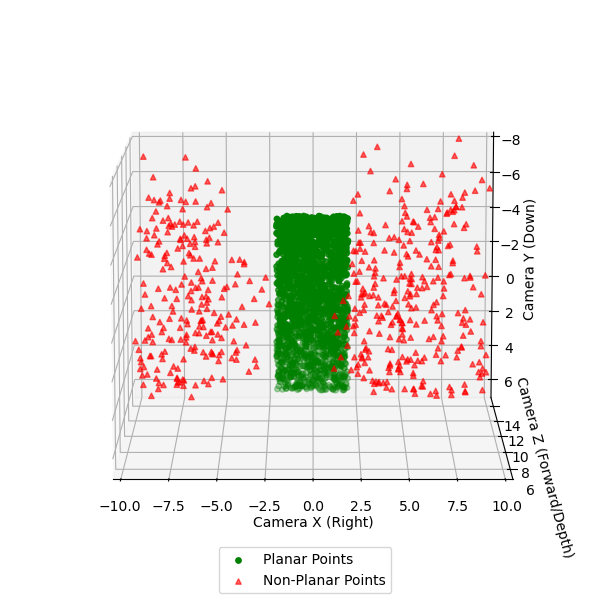

In [62]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import Image, display
# Create a new figure for the 3D plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Force the 3D axis to occupy almost the whole figure
#fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
ax.set_position([0, 0, 1, 1])

# 1. Plot the Planar Points 
# Mapping: Plot X = Cam X [0], Plot Y = Cam Z [2] (depth), Plot Z = Cam Y [1]
ax.scatter(keep_p3d[0, :np.sum(mask_plan)], 
           keep_p3d[2, :np.sum(mask_plan)], 
           keep_p3d[1, :np.sum(mask_plan)], 
           c='green', marker='o', s=15, label='Planar Points')

# 2. Plot the Non-Planar Points
ax.scatter(keep_p3d[0, np.sum(mask_plan):], 
           keep_p3d[2, np.sum(mask_plan):], 
           keep_p3d[1, np.sum(mask_plan):], 
           c='red', marker='^', s=15, alpha=0.6, label='Non-Planar Points')

# 3. Plot the Camera Trajectory (true_pos)
# Updated to match the (X, Z, Y) mapping of the points!
# ax.plot(true_pos[:, 0], 
#         true_pos[:, 2], 
#         true_pos[:, 1], 
#         c='green', marker='s', linewidth=2, label='Camera Trajectory')

# Add labels and title
ax.set_xlabel('Camera X (Right)')
ax.set_ylabel('Camera Z (Forward/Depth)')
ax.set_zlabel('Camera Y (Down)')

# INVERT THE Z-AXIS so that positive Y goes down, matching camera coordinates
ax.invert_zaxis()
ax.legend(loc='lower center')

ax.view_init(elev=10, azim=270)
ax.margins(0)
fig.tight_layout()
fig.subplots_adjust(top=5) 
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

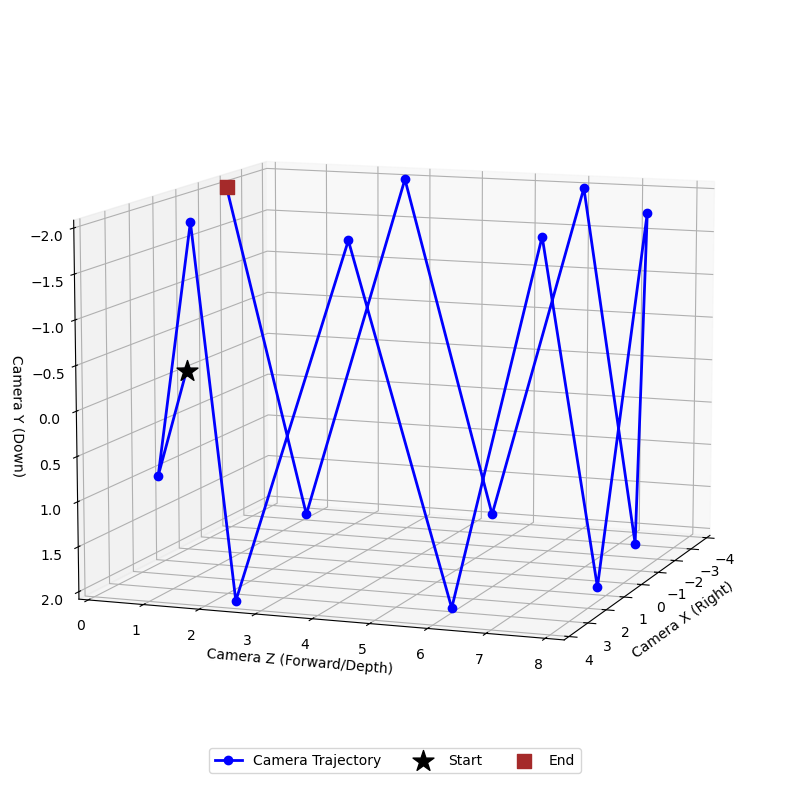

In [101]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import Image, display
# Create a new figure for the 3D plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Force the 3D axis to occupy almost the whole figure
#fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
#ax.set_position([0, 0, 1, 1])



ax.plot(true_pos[:, 0], 
        true_pos[:, 2], 
         true_pos[:, 1], 
        c='blue', marker='o', linewidth=2, label='Camera Trajectory')

ax.scatter(true_pos[0, 0], true_pos[0, 2], true_pos[0, 1], 
           color='black', marker='*', s=250, label='Start', zorder=5)

# End point (Last row: index -1) - Red Square
ax.scatter(true_pos[-1, 0], true_pos[-1, 2], true_pos[-1, 1], 
           color='brown', marker='s', s=100, label='End', zorder=5)
# Add labels and title
ax.set_xlabel('Camera X (Right)')
ax.set_ylabel('Camera Z (Forward/Depth)')
ax.set_zlabel('Camera Y (Down)')

# INVERT THE Z-AXIS so that positive Y goes down, matching camera coordinates
ax.invert_zaxis()
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.0001), ncol=3)

ax.view_init(elev=10, azim=20)
ax.margins(0)
fig.tight_layout()
fig.subplots_adjust(top=5) 
plt.show

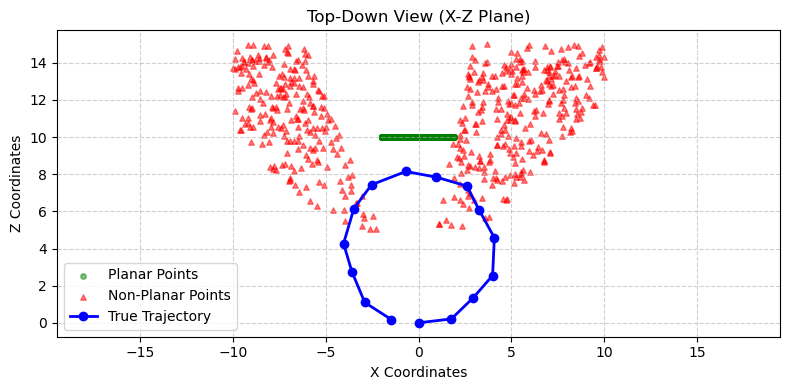

In [85]:
import matplotlib.pyplot as plt

# Create a standard 2D figure
fig, ax = plt.subplots(figsize=(8, 4))

# 1. Plot Planar Points (X vs Z)
ax.scatter(keep_p3d[0, :np.sum(mask_plan)], 
           keep_p3d[2, :np.sum(mask_plan)], 
           c='green', marker='o', s=15, alpha=0.5, label='Planar Points')

# 2. Plot Non-Planar Points (X vs Z)
ax.scatter(keep_p3d[0, np.sum(mask_plan):], 
           keep_p3d[2, np.sum(mask_plan):], 
           c='red', marker='^', s=15, alpha=0.5, label='Non-Planar Points')

# 3. Plot Camera Trajectory (X vs Z)
# zorder=3 ensures the trajectory line is drawn ON TOP of the scatter points
ax.plot(true_pos[:, 0], 
        true_pos[:, 2], 
        c='blue', marker='o', linewidth=2, label='True Trajectory', zorder=3)

# 4. NEW: Add Field of View (FOV) Triangles

# 4. Formatting
ax.set_title('Top-Down View (X-Z Plane)')
ax.set_xlabel('X Coordinates')
ax.set_ylabel('Z Coordinates')

# CRITICAL STEP FOR TOP-DOWN VIEWS: 
# This forces the X and Y axes to have the exact same scale, 
# ensuring your trajectory and walls don't look stretched or squished!
ax.set_aspect('equal', adjustable='datalim')

# Add grid and legend
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()

# Clean up layout
plt.tight_layout()

# Display the plot
plt.show()

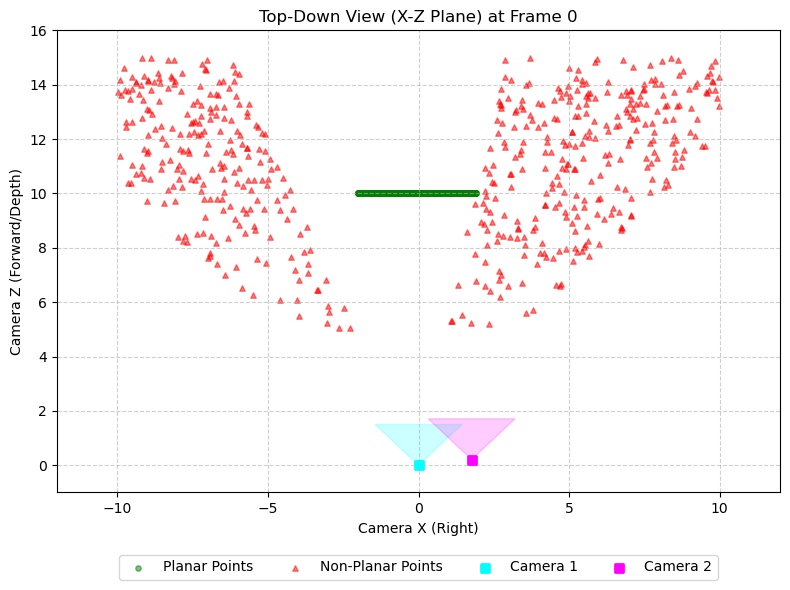

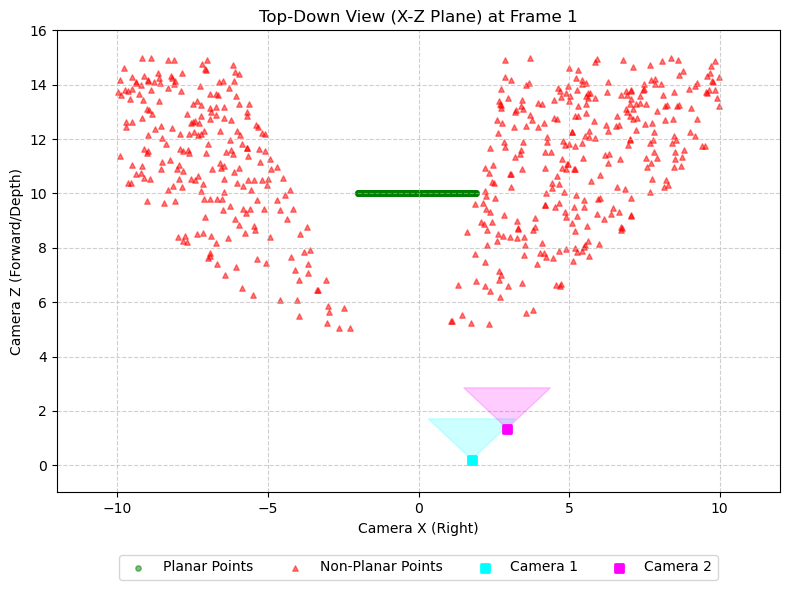

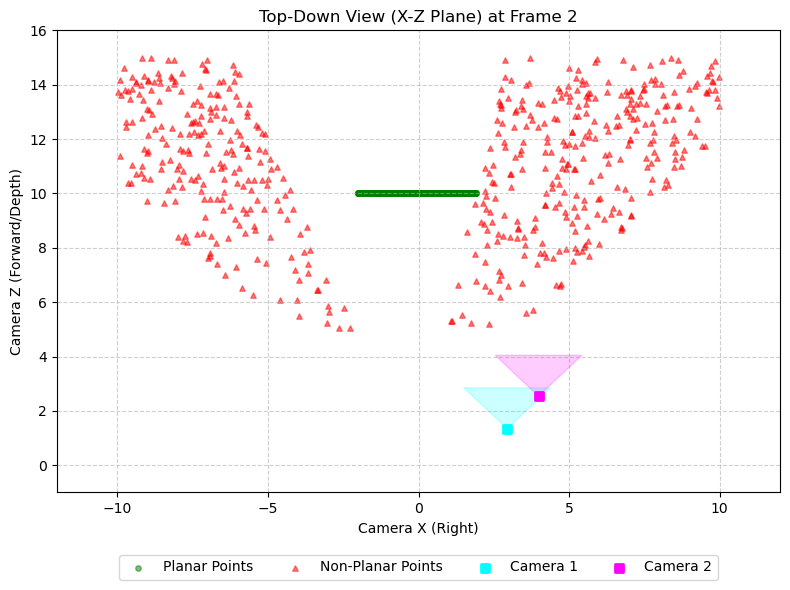

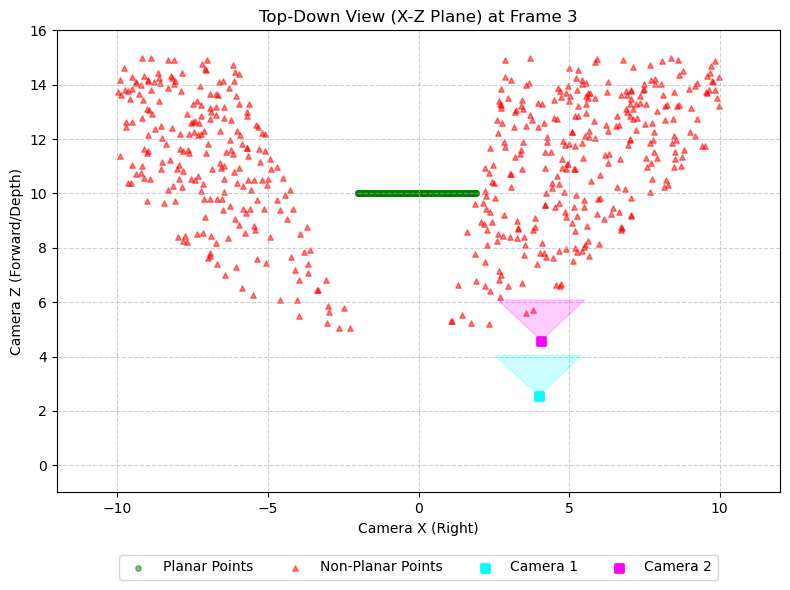

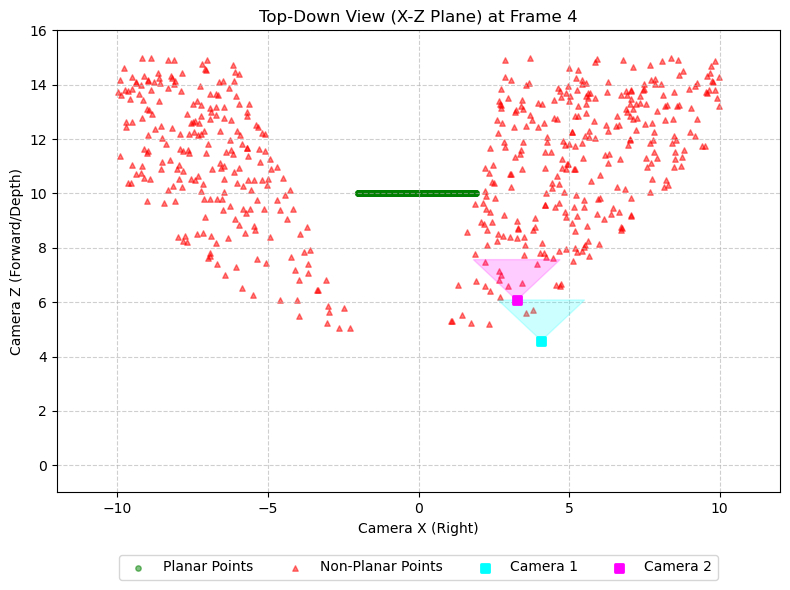

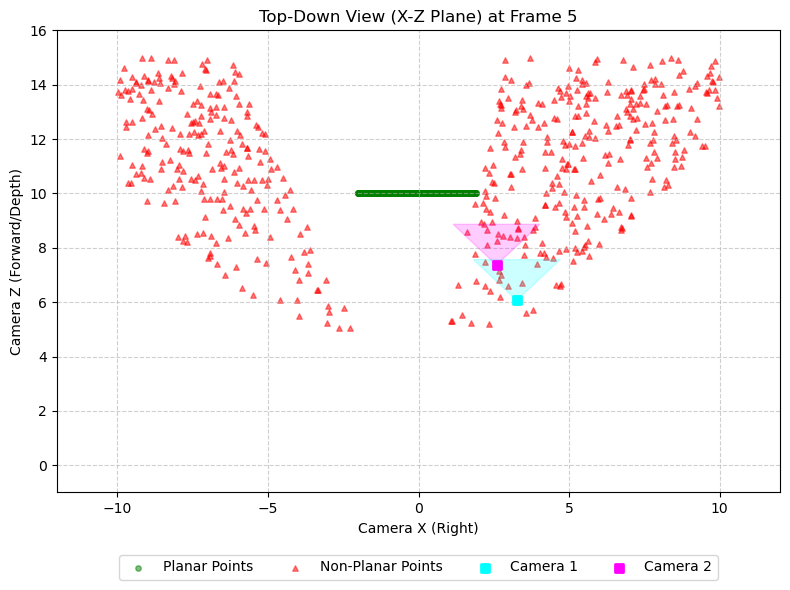

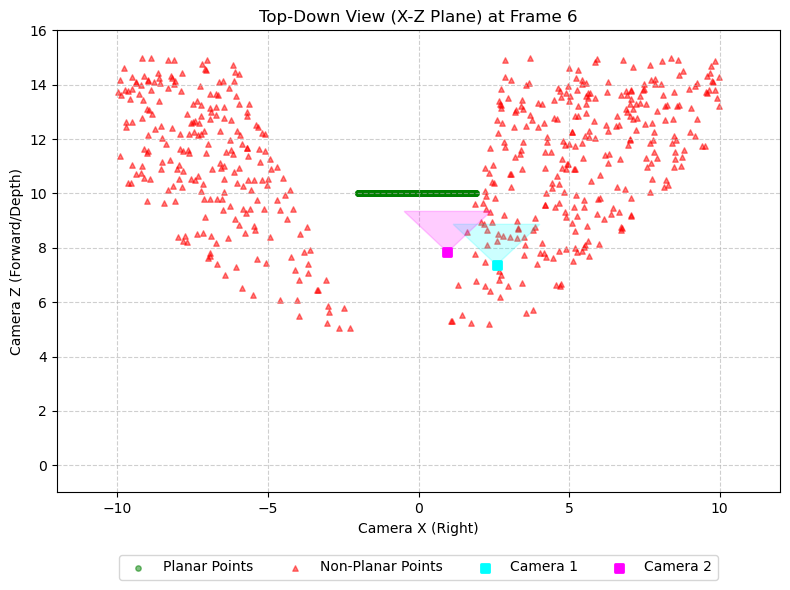

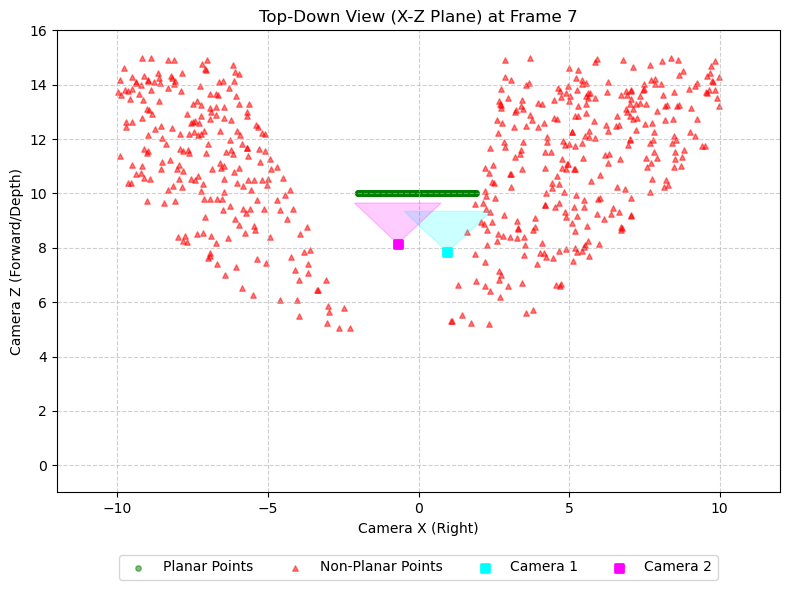

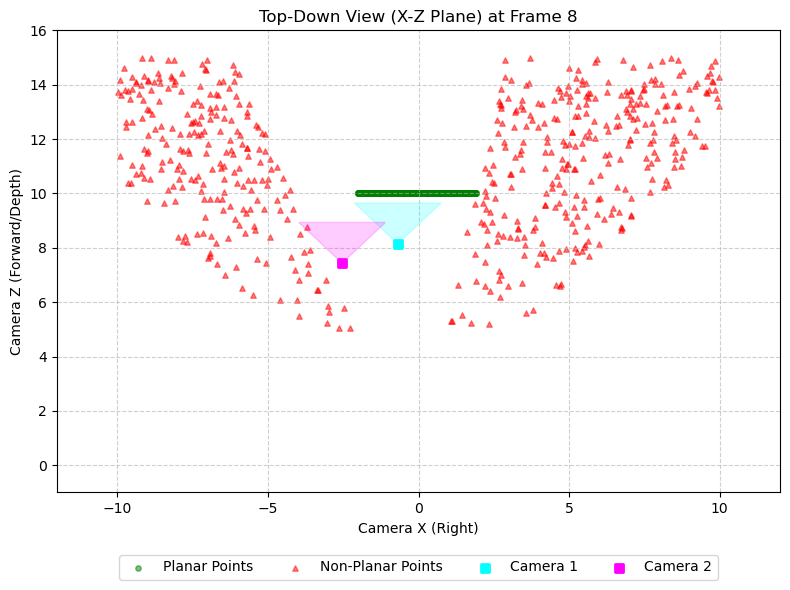

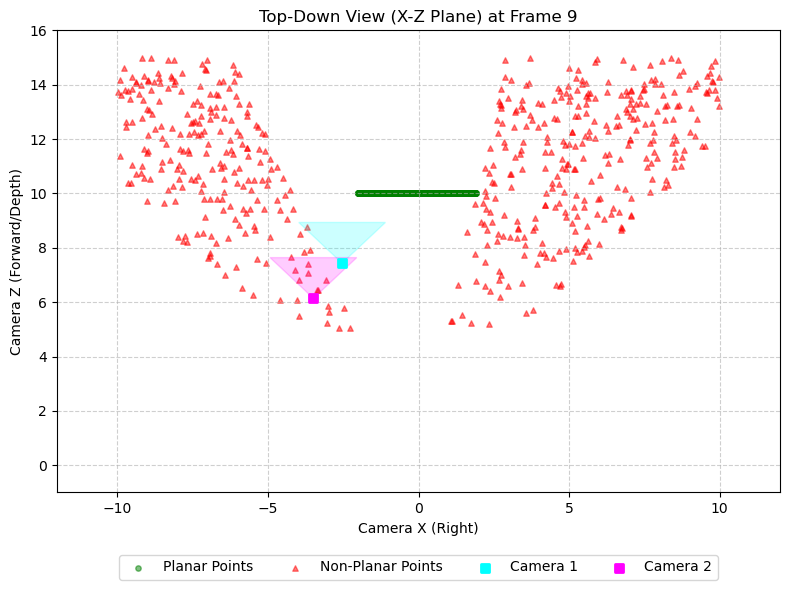

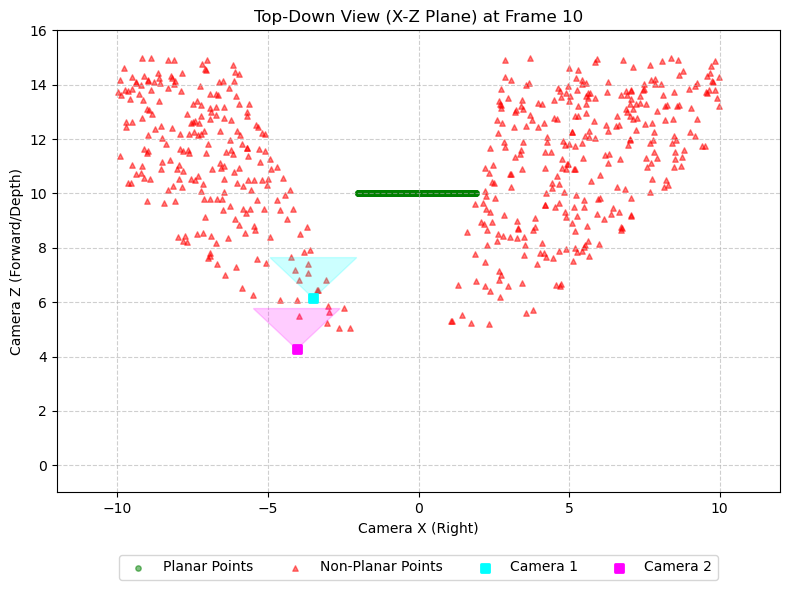

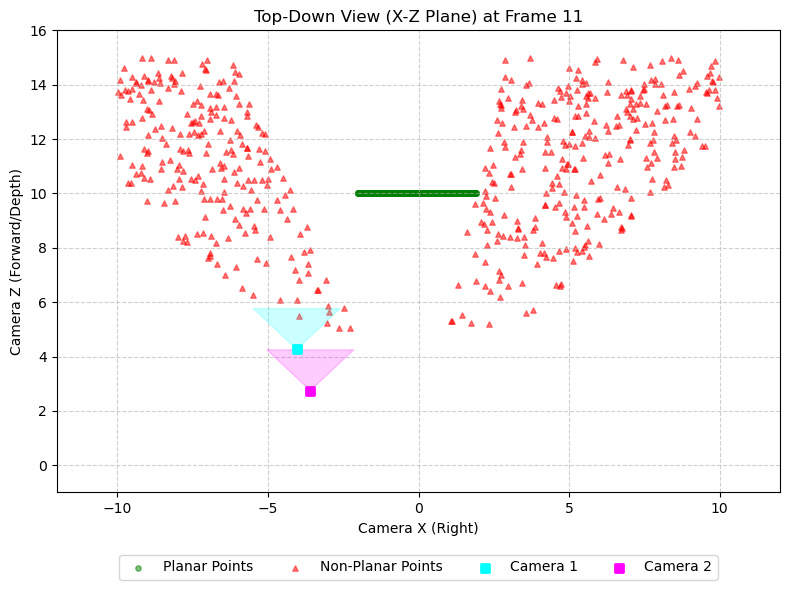

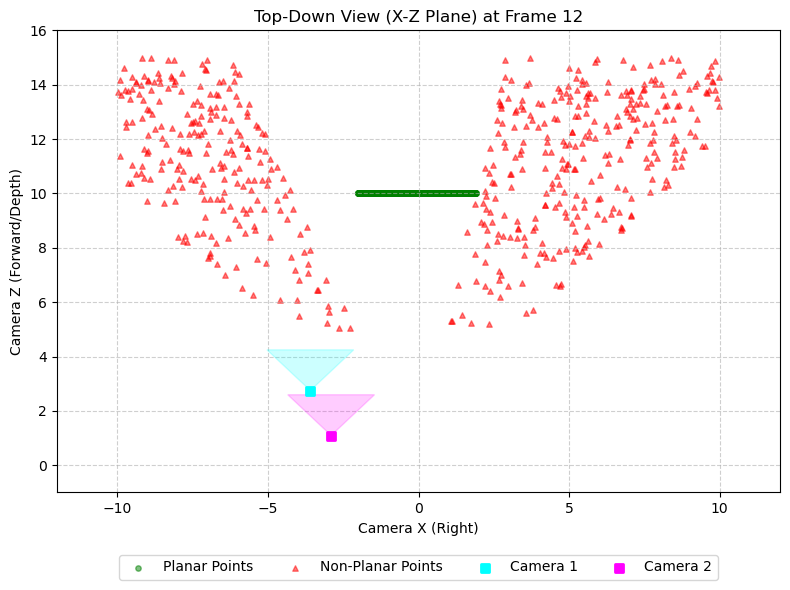

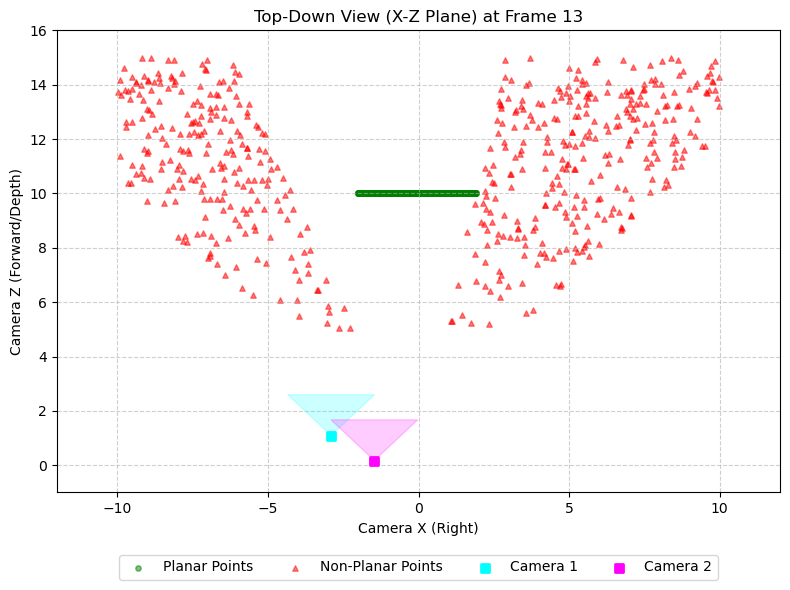

In [78]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np

# Pre-calculate the FOV triangle width (so we don't calculate it every loop)
fov_angle = 87.66
fov_depth = 1.5
half_angle = np.radians(fov_angle / 2)
dx = fov_depth * np.tan(half_angle)

for i in range(nb_pose - 1):
    # Create a standard 2D figure
    fig, ax = plt.subplots(figsize=(8, 6))

    # 1. Plot Planar Points (X vs Z)
    ax.scatter(keep_p3d[0, :np.sum(mask_plan)], 
               keep_p3d[2, :np.sum(mask_plan)], 
               c='green', marker='o', s=15, alpha=0.5, label='Planar Points')

    # 2. Plot Non-Planar Points (X vs Z)
    ax.scatter(keep_p3d[0, np.sum(mask_plan):], 
               keep_p3d[2, np.sum(mask_plan):], 
               c='red', marker='^', s=15, alpha=0.5, label='Non-Planar Points')

    # --- 3. CAMERA 1 (Current Frame) ---
    cx1, cz1 = true_pos[i, 0], true_pos[i, 2]
    ax.scatter(cx1, cz1, c='cyan', marker='s', linewidth=2, label='Camera 1', zorder=3)
    
    # FOV Triangle Camera 1
    fov1 = Polygon([[cx1, cz1], [cx1 - dx, cz1 + fov_depth], [cx1 + dx, cz1 + fov_depth]], 
                   closed=True, color='cyan', alpha=0.2, zorder=2)
    ax.add_patch(fov1)

    # --- 4. CAMERA 2 (Next Frame) ---
    cx2, cz2 = true_pos[i+1, 0], true_pos[i+1, 2]
    ax.scatter(cx2, cz2, c='magenta', marker='s', linewidth=2, label='Camera 2', zorder=3)
    
    # FOV Triangle Camera 2
    fov2 = Polygon([[cx2, cz2], [cx2 - dx, cz2 + fov_depth], [cx2 + dx, cz2 + fov_depth]], 
                   closed=True, color='magenta', alpha=0.2, zorder=2)
    ax.add_patch(fov2)

    # --- 5. Formatting & Layout ---
    # Add the dynamic frame number to the title using an f-string!
    ax.set_title(f'Top-Down View (X-Z Plane) at Frame {i}')
    ax.set_xlabel('Camera X (Right)')
    ax.set_ylabel('Camera Z (Forward/Depth)')
    ax.set_xlim(-12, 12)
    ax.set_ylim(-1, 16)
    # Maintain 1:1 aspect ratio
    ax.grid(True, linestyle='--', alpha=0.6)

    # Place legend underneath to save space in the 8x4 window
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4)

    plt.tight_layout()
    plt.show()

[[ 0.          0.          0.        ]
 [ 1.7639246   1.          0.20943753]
 [ 2.94201852 -2.          1.35076997]
 [ 3.98352503  2.          2.54584065]
 [ 4.0767716  -2.          4.58192944]
 [ 3.26119029  2.          6.0658322 ]
 [ 2.58895218 -2.          7.36511185]
 [ 0.96221661  2.          7.83985339]
 [-0.68861461 -2.          8.14793942]
 [-2.53708419  2.          7.43262854]
 [-3.48890865 -2.          6.13919175]
 [-4.04268857  2.          4.26543321]
 [-3.59084357 -2.          2.74729252]
 [-2.90064674  2.          1.09537946]
 [-1.46556577 -2.          0.17296292]]


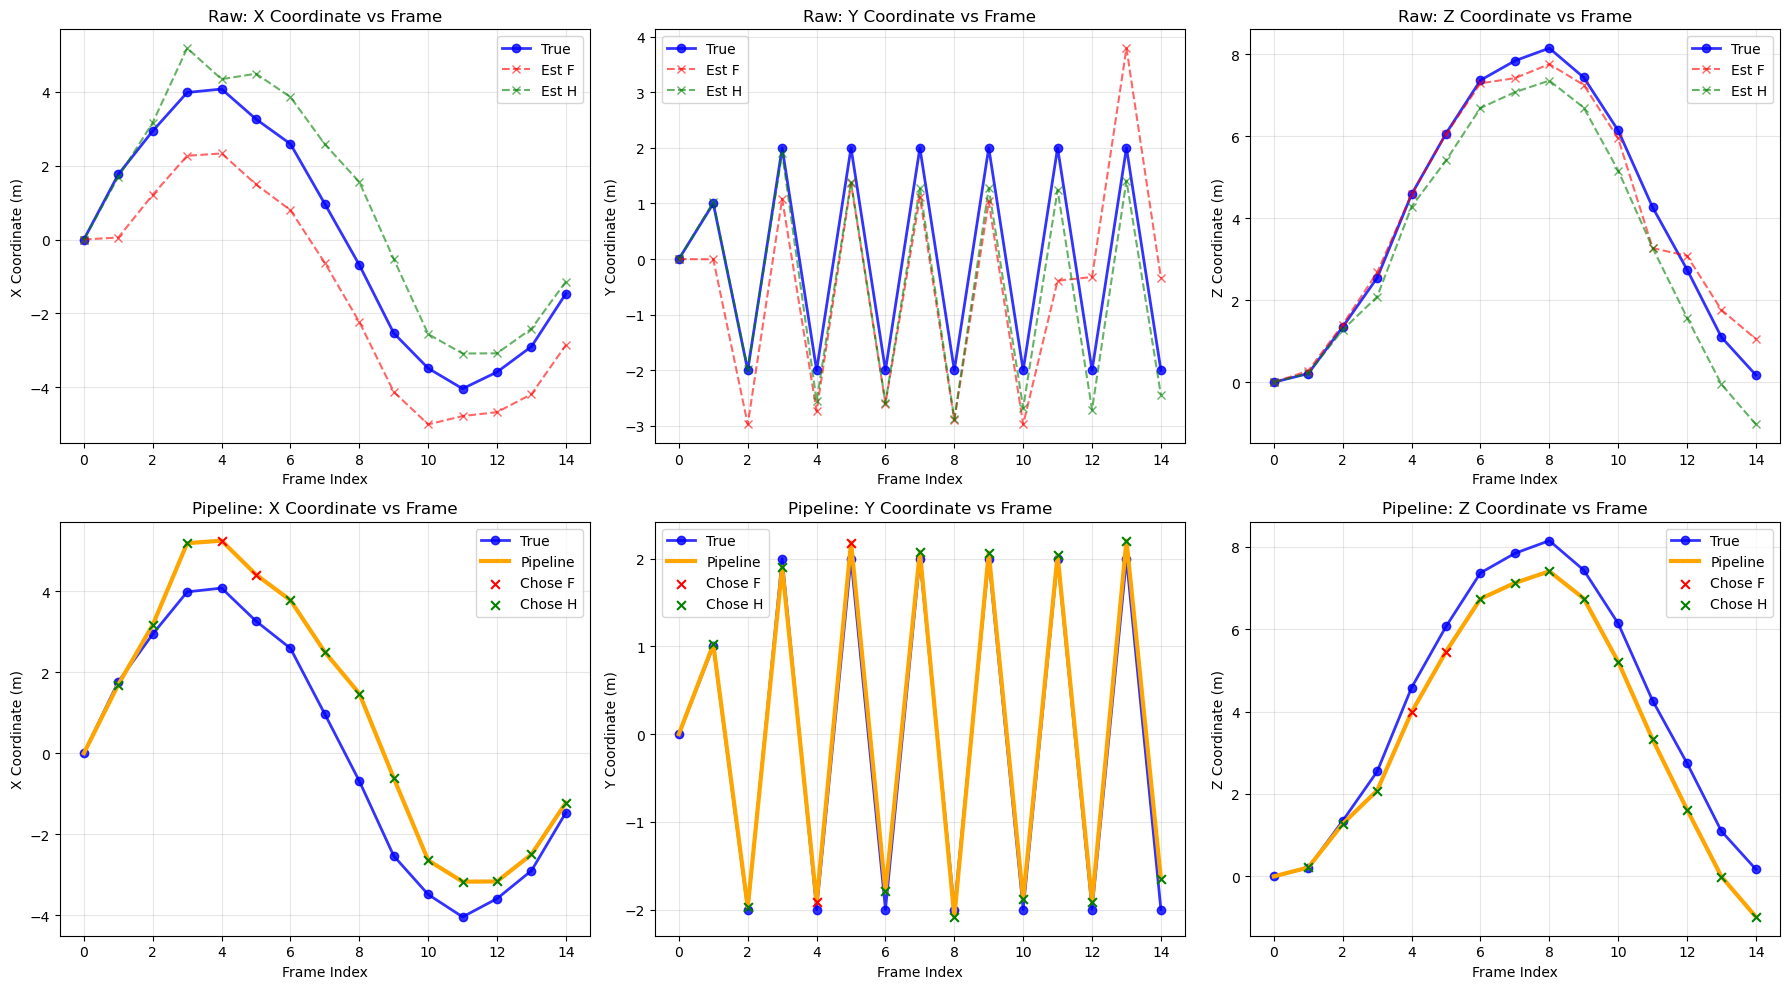

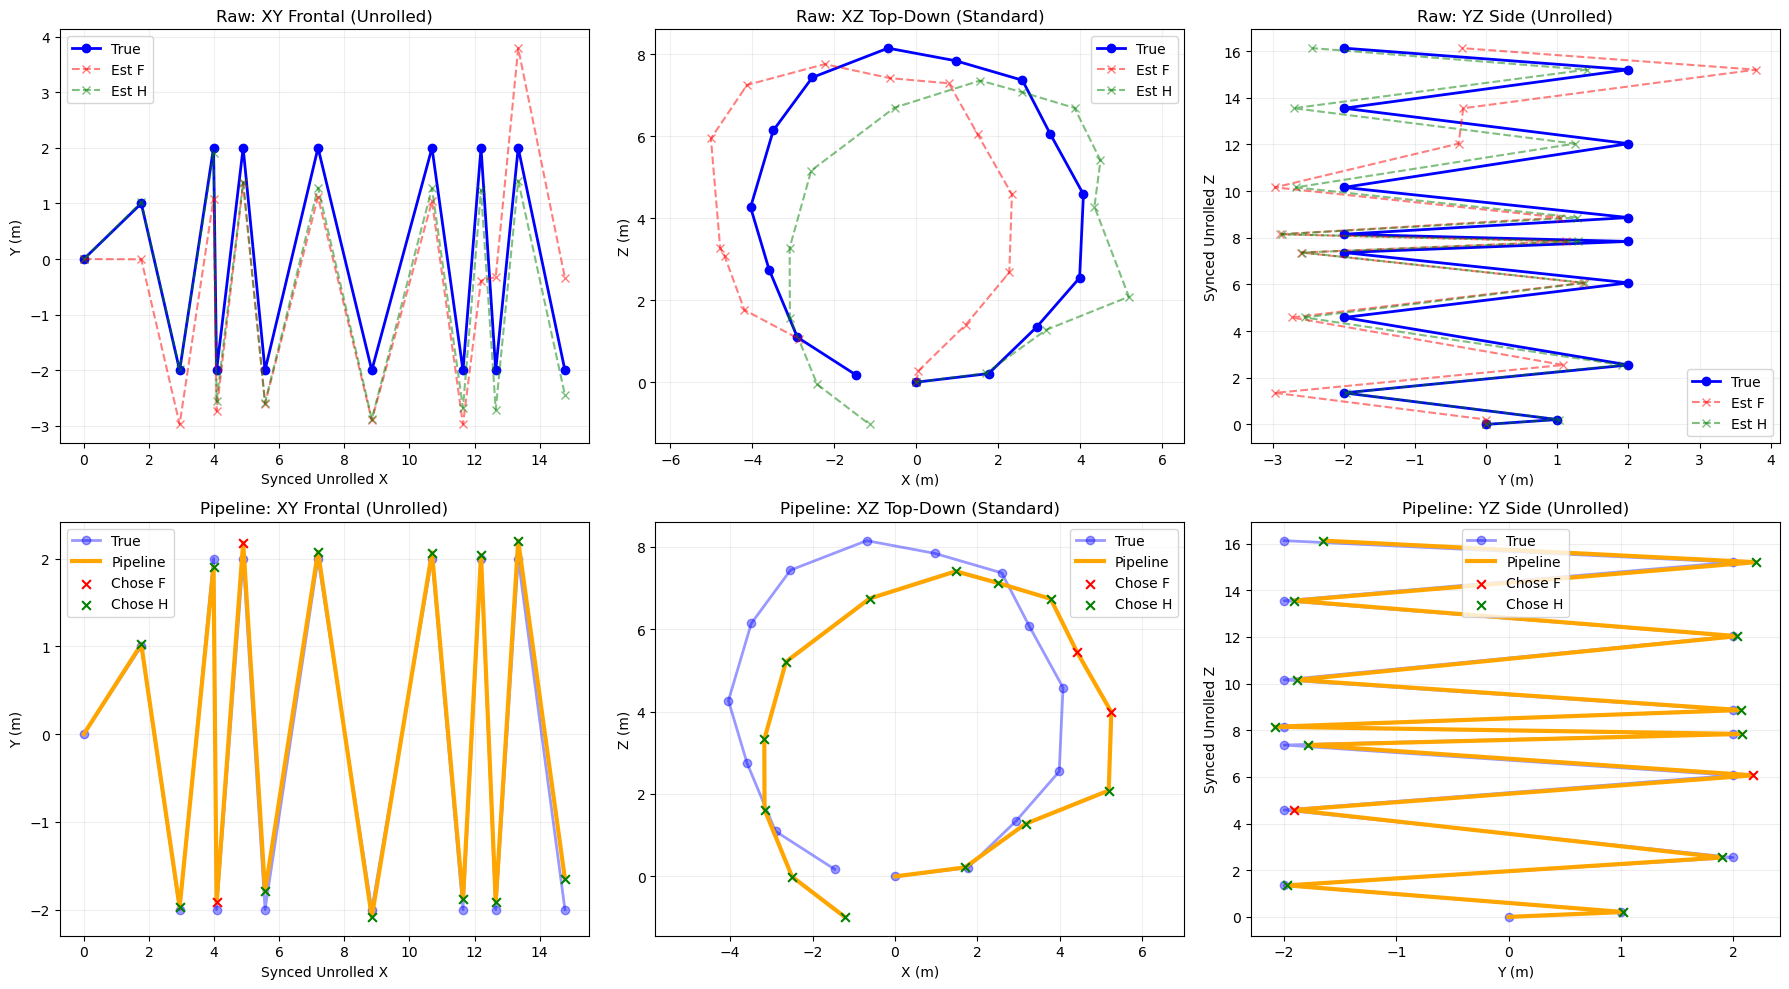

<Figure size 640x480 with 0 Axes>

Average Relative Translation Error: 8.75%
Average Relative Translation Error: 20.37%
Average Relative Translation Error: 11.60%


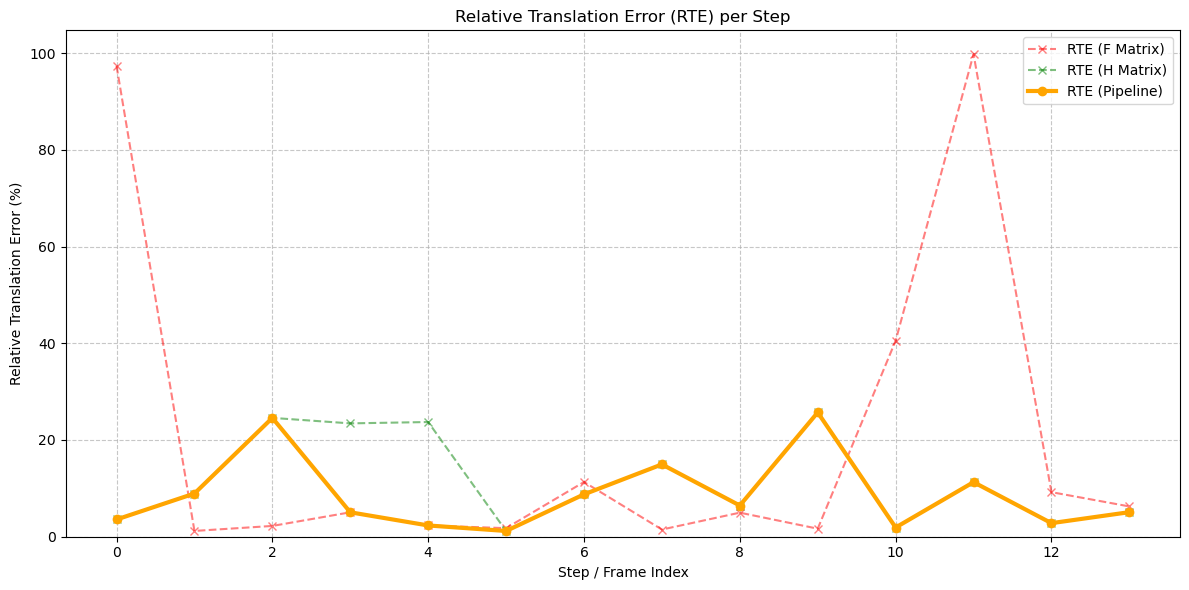

Mean Relative Rotation Error: 1.4316 degrees per step
Mean Relative Rotation Error: 2.6092 degrees per step
Mean Relative Rotation Error: 2.1480 degrees per step


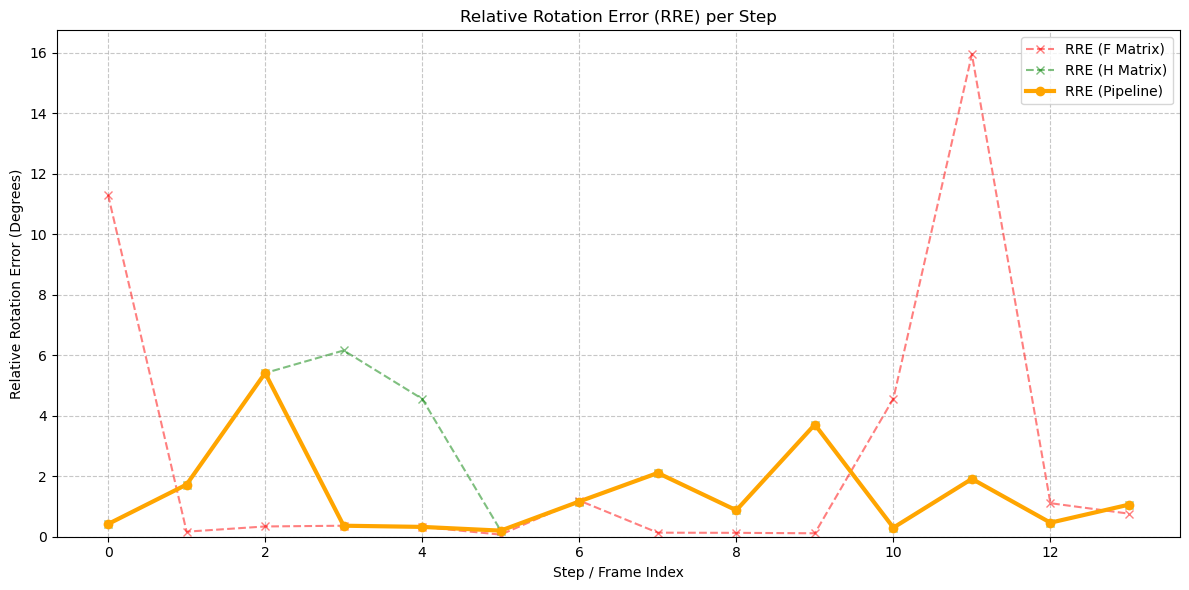

Average Relative Translation Error: 8.75%
Average Relative Translation Error: 20.37%
Average Relative Translation Error: 11.60%


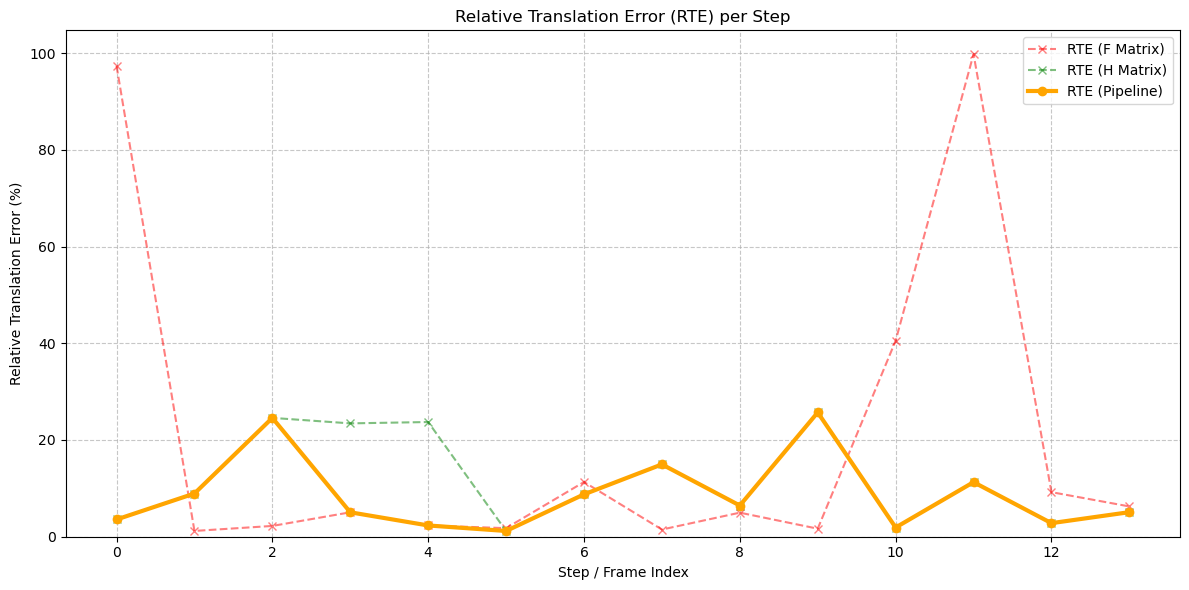

Mean Relative Rotation Error: 1.4316 degrees per step
Mean Relative Rotation Error: 2.6092 degrees per step
Mean Relative Rotation Error: 2.1480 degrees per step


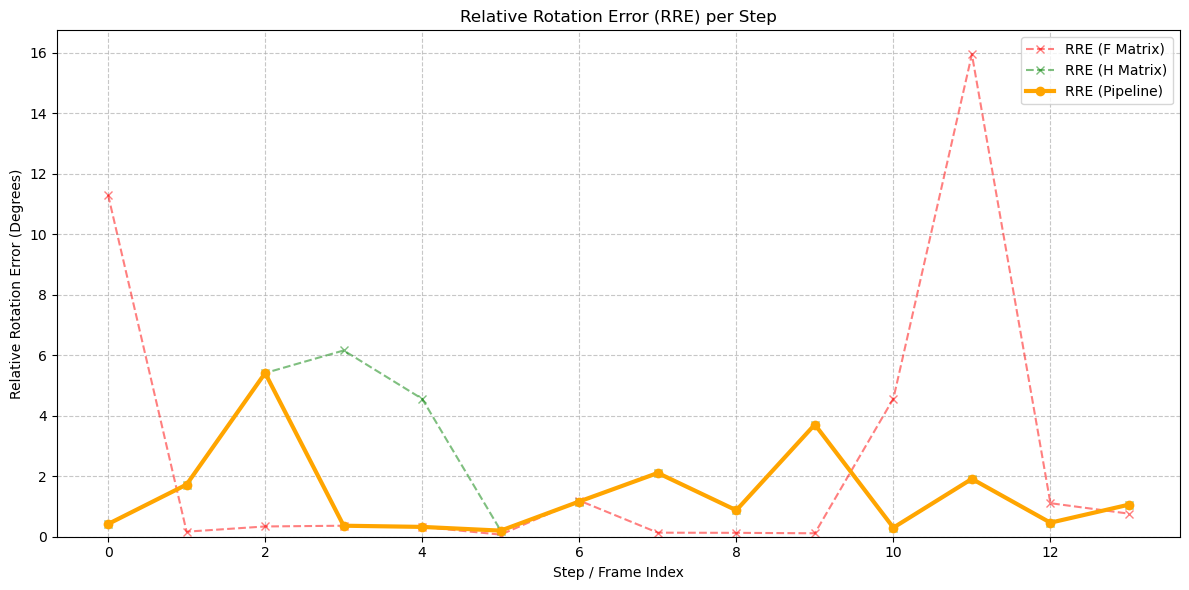

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
threshold = 0.45
for i in range (nb_pose-1):
    est_t_score[i, :] = est_t_H[i,:] if score_ratio[i] > threshold else est_t_F[i,:] 
    est_r_score[i, :] = est_r_H[i,:] if score_ratio[i] > threshold else est_r_F[i,:] 

true_pos = np.zeros((nb_pose, 3))
est_pos_F = np.zeros((nb_pose, 3))
est_pos_H = np.zeros((nb_pose, 3))
est_pos_score = np.zeros((nb_pose, 3))

for i in range(nb_pose-1):
    true_pos[i+1, :] = translate_point(true_pos[i, :], true_t[i, :])
    est_pos_F[i+1, :] = translate_point(est_pos_F[i, :], est_t_F[i, :])
    est_pos_H[i+1, :] = translate_point(est_pos_H[i, :], est_t_H[i, :])
    est_pos_score[i+1, :] = translate_point(est_pos_score[i, :], est_t_score[i, :])


# Create the figure: 2 rows (Raw vs Pipeline), 3 columns (X, Y, Z coordinates)
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# Helper lists
dims = ['X Coordinate', 'Y Coordinate', 'Z Coordinate']
# Create a frame index for the x-axis
frames = np.arange(nb_pose)

# Prepare decision mask (Ensure it matches the length of the steps)
pts_from_1 = est_pos_score[1:]
used_F = score_ratio[:14] < threshold
pipeline_F = np.full((len(used_F),3), np.nan)
pipeline_H = np.full((15 - len(used_F),3), np.nan)
pipeline_F = pts_from_1[used_F]   
pipeline_H= pts_from_1[~used_F]

# ==========================================
# ROW 1: Raw Math (True vs F vs H) - Over Time
# ==========================================
for i in range(3):
    ax = axs[0, i]
    # Ground Truth
    ax.plot(frames, true_pos[:, i], label='True', marker='o', color='blue', lw=2, alpha=0.8)
    # F Matrix estimate
    ax.plot(frames, est_pos_F[:, i], label='Est F', marker='x', color='red', linestyle='--', alpha=0.6)
    # H Matrix estimate
    ax.plot(frames, est_pos_H[:, i], label='Est H', marker='x', color='green', linestyle='--', alpha=0.6)
    
    ax.set_title(f"Raw: {dims[i]} vs Frame")
    ax.set_xlabel("Frame Index")
    ax.set_ylabel(f"{dims[i]} (m)")
    ax.legend()
    ax.grid(True, alpha=0.3)

# ==========================================
# ROW 2: Final Pipeline (True vs Score) - Over Time
# ==========================================
for i in range(3):
    ax = axs[1, i]
    # Ground Truth
    ax.plot(frames, true_pos[:, i], label='True', color='blue', marker='o', lw=2, alpha=0.8)
    # Final Pipeline result
    ax.plot(frames, est_pos_score[:, i], label='Pipeline', color='orange', linewidth=3)
    
    # Scatter markers for decisions (starting from frame 1)
    # We use np.where to get the indices where used_F is True/False
    ax.scatter(np.where(used_F)[0] + 1, est_pos_score[1:][used_F, i], 
               color='red', s=40, zorder=5, label='Chose F', marker='x')
    ax.scatter(np.where(~used_F)[0] + 1, est_pos_score[1:][~used_F, i], 
               color='green', s=40, zorder=5, label='Chose H', marker='x')
    
    ax.set_title(f"Pipeline: {dims[i]} vs Frame")
    ax.set_xlabel("Frame Index")
    ax.set_ylabel(f"{dims[i]} (m)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
def unroll_axis(arr):
    """
    Converts oscillating coordinates into a continuous path by 
    calculating cumulative distance. This prevents spatial overlap.
    """
    diffs = np.abs(np.diff(arr))
    unrolled = np.zeros_like(arr)
    unrolled[1:] = np.cumsum(diffs)
    return unrolled

un_x_true = unroll_axis(true_pos[:, 0])
un_x_pipe = unroll_axis(est_pos_score[:, 0])
un_x_F    = unroll_axis(est_pos_F[:, 0])
un_x_H    = unroll_axis(est_pos_H[:, 0])

un_z_true = unroll_axis(true_pos[:, 2])
un_z_pipe = unroll_axis(est_pos_score[:, 2])
un_z_F    = unroll_axis(est_pos_F[:, 2])
un_z_H    = unroll_axis(est_pos_H[:, 2])


# ==========================================
pts_from_1 = est_pos_score[1:]
used_F = score_ratio[:14] < threshold
pipeline_F = np.full((len(used_F),3), np.nan)
pipeline_H = np.full((15 - len(used_F),3), np.nan)
pipeline_F = pts_from_1[used_F]   
pipeline_H= pts_from_1[~used_F]
un_x_sync = unroll_axis(true_pos[:, 0])
un_z_sync = unroll_axis(true_pos[:, 2])

# 2. Create the Figure
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# Pre-calculate decision mask dynamically
used_F = score_ratio[:len(est_pos_score)-1] < threshold

for row in range(2):
    for col in range(3):
        ax = axs[row, col]
        
        # --- COORDINATE MAPPING ---
        if col == 0: # XY Frontal (Unrolled X for readability)
            h_t, h_f, h_h, h_p = un_x_sync, un_x_sync, un_x_sync, un_x_sync
            v_t, v_f, v_h, v_p = true_pos[:, 1], est_pos_F[:, 1], est_pos_H[:, 1], est_pos_score[:, 1]
            ax.set_xlabel("Synced Unrolled X"); ax.set_ylabel("Y (m)")
            title_suffix = "XY Frontal (Unrolled)"
            
        elif col == 1: # XZ Top-Down (STANDARD X, STANDARD Z)
            h_t, h_f, h_h, h_p = true_pos[:, 0], est_pos_F[:, 0], est_pos_H[:, 0], est_pos_score[:, 0]
            v_t, v_f, v_h, v_p = true_pos[:, 2], est_pos_F[:, 2], est_pos_H[:, 2], est_pos_score[:, 2]
            ax.set_xlabel("X (m)"); ax.set_ylabel("Z (m)")
            title_suffix = "XZ Top-Down (Standard)"
            ax.axis('equal') # Keep the map proportions correct
            
        else: # YZ Side (Unrolled Z for readability)
            h_t, h_f, h_h, h_p = true_pos[:, 1], est_pos_F[:, 1], est_pos_H[:, 1], est_pos_score[:, 1]
            v_t, v_f, v_h, v_p = un_z_sync, un_z_sync, un_z_sync, un_z_sync
            ax.set_xlabel("Y (m)"); ax.set_ylabel("Synced Unrolled Z")
            title_suffix = "YZ Side (Unrolled)"

        # --- PLOTTING ---
        if row == 0: # RAW ROW
            ax.plot(h_t, v_t, 'b-',marker ='o', lw=2, label='True')
            ax.plot(h_f, v_f, 'r--',marker ='x', alpha=0.5, label='Est F')
            ax.plot(h_h, v_h, 'g--', marker ='x',alpha=0.5, label='Est H')
            ax.set_title(f"Raw: {title_suffix}")
        else: # PIPELINE ROW
            ax.plot(h_t, v_t, 'b-', marker ='o',lw=2, alpha=0.4, label='True')
            ax.plot(h_p, v_p, color='orange', lw=3, label='Pipeline')
            
            # Decision Markers
            ax.scatter(h_p[1:][used_F], v_p[1:][used_F], color='red', marker='x', s=40, zorder=5, label='Chose F')
            ax.scatter(h_p[1:][~used_F], v_p[1:][~used_F], color='green', marker='x', s=40, zorder=5, label='Chose H')
            ax.set_title(f"Pipeline: {title_suffix}")

        ax.grid(True, alpha=0.2)
        ax.legend(loc='best')

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

true_deltas = np.diff(true_pos, axis=0)
est_deltas  = np.diff(est_pos_score, axis=0)

# 2. Calculate the magnitude of the error vector for each step
error_vectors = est_deltas - true_deltas
rte_raw = np.linalg.norm(error_vectors, axis=1) # Error in units (e.g. meters)

# 3. Calculate normalized RTE (Error as a percentage of step length)
step_lengths = np.linalg.norm(true_deltas, axis=1)
rte_percent = (rte_raw / step_lengths) * 100

# 4. Final Metric: Mean RTE
mean_rte = np.mean(rte_percent)
print(f"Average Relative Translation Error: {mean_rte:.2f}%")

# F matrix
true_deltas = np.diff(true_pos, axis=0)
est_deltas  = np.diff(est_pos_F, axis=0)

# 2. Calculate the magnitude of the error vector for each step
error_vectors = est_deltas - true_deltas
rte_raw = np.linalg.norm(error_vectors, axis=1) # Error in units (e.g. meters)

# 3. Calculate normalized RTE (Error as a percentage of step length)
step_lengths = np.linalg.norm(true_deltas, axis=1)
rte_percent_F = (rte_raw / step_lengths) * 100

# 4. Final Metric: Mean RTE
mean_rte = np.mean(rte_percent_F)
print(f"Average Relative Translation Error: {mean_rte:.2f}%")

# H matrix
true_deltas = np.diff(true_pos, axis=0)
est_deltas  = np.diff(est_pos_H, axis=0)

# 2. Calculate the magnitude of the error vector for each step
error_vectors = est_deltas - true_deltas
rte_raw = np.linalg.norm(error_vectors, axis=1) # Error in units (e.g. meters)

# 3. Calculate normalized RTE (Error as a percentage of step length)
step_lengths = np.linalg.norm(true_deltas, axis=1)
rte_percent_H = (rte_raw / step_lengths) * 100

# 4. Final Metric: Mean RTE
mean_rte = np.mean(rte_percent_H)
print(f"Average Relative Translation Error: {mean_rte:.2f}%")

plt.figure(figsize=(12, 6))

# Plot the Raw F and H Errors (Faded into the background)
plt.plot(rte_percent_F, label='RTE (F Matrix)', 
         color='red', marker='x', linestyle='--', alpha=0.5)

plt.plot(rte_percent_H, label='RTE (H Matrix)', 
         color='green', marker='x', linestyle='--', alpha=0.5)

# Plot your Pipeline Error (Bold and brought to the front)
plt.plot(rte_percent, label='RTE (Pipeline)', 
         color='orange', linewidth=3, marker='o', zorder=5)

# Formatting the plot
plt.title('Relative Translation Error (RTE) per Step')
plt.xlabel('Step / Frame Index')
plt.ylabel('Relative Translation Error (%)')

# Set the bottom of the y-axis to 0% for proper perspective
plt.ylim(bottom=0) 

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

import numpy as np
from scipy.spatial.transform import Rotation as R

def calculate_step_rre(true_angles, est_angles):
    """
    Calculates the Relative Rotation Error (RRE) in degrees.
    true_angles, est_angles: [rx, ry, rz] in degrees
    """
    # 1. Convert Euler angles to Rotation Matrices
    # Using 'xyz' or 'zyx' depending on your simulator's convention
    r_true = R.from_euler('xyz', true_angles, degrees=True).as_matrix()
    r_est = R.from_euler('xyz', est_angles, degrees=True).as_matrix()
    
    # 2. Compute the relative rotation matrix
    # This represents the "rotation difference"
    r_diff = np.dot(r_true.T, r_est)
    
    # 3. Calculate the angle of this rotation (the Geodesic distance)
    # Formula: acos((trace(R_diff) - 1) / 2)
    cos_theta = (np.trace(r_diff) - 1.0) / 2.0
    
    # Clip to avoid floating point errors outside [-1, 1]
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    
    return np.degrees(np.arccos(cos_theta))

# --- Application ---
# Assuming est_r_score and true_r are arrays of shape (nb_pose, 3)
rre_per_step = []

for i in range(nb_pose - 1):
    # We compare the estimated rotation of the step to the true rotation
    error = calculate_step_rre(true_r[i], est_r_score[i])
    rre_per_step.append(error)

mean_rre = np.mean(rre_per_step)
print(f"Mean Relative Rotation Error: {mean_rre:.4f} degrees per step")

rre_per_step_F = []
# F
for i in range(nb_pose - 1):
    # We compare the estimated rotation of the step to the true rotation
    error = calculate_step_rre(true_r[i], est_r_F[i])
    rre_per_step_F.append(error)

mean_rre_F = np.mean(rre_per_step_F)
print(f"Mean Relative Rotation Error: {mean_rre_F:.4f} degrees per step")
rre_per_step_H = []
# H
for i in range(nb_pose - 1):
    # We compare the estimated rotation of the step to the true rotation
    error = calculate_step_rre(true_r[i], est_r_H[i])
    rre_per_step_H.append(error)

mean_rre_H = np.mean(rre_per_step_H)
print(f"Mean Relative Rotation Error: {mean_rre_H:.4f} degrees per step")

plt.figure(figsize=(12, 6))

# Plot the Raw F and H Rotation Errors (Faded into the background)
plt.plot(rre_per_step_F, label='RRE (F Matrix)', 
         color='red', marker='x', linestyle='--', alpha=0.5)

plt.plot(rre_per_step_H, label='RRE (H Matrix)', 
         color='green', marker='x', linestyle='--', alpha=0.5)

# Plot your Pipeline's Rotation Error (Bold and brought to the front)
plt.plot(rre_per_step, label='RRE (Pipeline)', 
         color='orange', linewidth=3, marker='o', zorder=5)

# Formatting the plot
plt.title('Relative Rotation Error (RRE) per Step')
plt.xlabel('Step / Frame Index')
plt.ylabel('Relative Rotation Error (Degrees)')

# Set the bottom of the y-axis to 0 degrees for proper perspective
plt.ylim(bottom=0) 

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

true_deltas = np.diff(true_pos, axis=0)
est_deltas  = np.diff(est_pos_score, axis=0)

# 2. Calculate the magnitude of the error vector for each step
error_vectors = est_deltas - true_deltas
rte_raw = np.linalg.norm(error_vectors, axis=1) # Error in units (e.g. meters)

# 3. Calculate normalized RTE (Error as a percentage of step length)
step_lengths = np.linalg.norm(true_deltas, axis=1)
rte_percent = (rte_raw / step_lengths) * 100

# 4. Final Metric: Mean RTE
mean_rte = np.mean(rte_percent)
print(f"Average Relative Translation Error: {mean_rte:.2f}%")

# F matrix
true_deltas = np.diff(true_pos, axis=0)
est_deltas  = np.diff(est_pos_F, axis=0)

# 2. Calculate the magnitude of the error vector for each step
error_vectors = est_deltas - true_deltas
rte_raw = np.linalg.norm(error_vectors, axis=1) # Error in units (e.g. meters)

# 3. Calculate normalized RTE (Error as a percentage of step length)
step_lengths = np.linalg.norm(true_deltas, axis=1)
rte_percent_F = (rte_raw / step_lengths) * 100

# 4. Final Metric: Mean RTE
mean_rte = np.mean(rte_percent_F)
print(f"Average Relative Translation Error: {mean_rte:.2f}%")

# H matrix
true_deltas = np.diff(true_pos, axis=0)
est_deltas  = np.diff(est_pos_H, axis=0)

# 2. Calculate the magnitude of the error vector for each step
error_vectors = est_deltas - true_deltas
rte_raw = np.linalg.norm(error_vectors, axis=1) # Error in units (e.g. meters)

# 3. Calculate normalized RTE (Error as a percentage of step length)
step_lengths = np.linalg.norm(true_deltas, axis=1)
rte_percent_H = (rte_raw / step_lengths) * 100

# 4. Final Metric: Mean RTE
mean_rte = np.mean(rte_percent_H)
print(f"Average Relative Translation Error: {mean_rte:.2f}%")

plt.figure(figsize=(12, 6))

# Plot the Raw F and H Errors (Faded into the background)
plt.plot(rte_percent_F, label='RTE (F Matrix)', 
         color='red', marker='x', linestyle='--', alpha=0.5)

plt.plot(rte_percent_H, label='RTE (H Matrix)', 
         color='green', marker='x', linestyle='--', alpha=0.5)

# Plot your Pipeline Error (Bold and brought to the front)
plt.plot(rte_percent, label='RTE (Pipeline)', 
         color='orange', linewidth=3, marker='o', zorder=5)

# Formatting the plot
plt.title('Relative Translation Error (RTE) per Step')
plt.xlabel('Step / Frame Index')
plt.ylabel('Relative Translation Error (%)')

# Set the bottom of the y-axis to 0% for proper perspective
plt.ylim(bottom=0) 

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

import numpy as np
from scipy.spatial.transform import Rotation as R

def calculate_step_rre(true_angles, est_angles):
    """
    Calculates the Relative Rotation Error (RRE) in degrees.
    true_angles, est_angles: [rx, ry, rz] in degrees
    """
    # 1. Convert Euler angles to Rotation Matrices
    # Using 'xyz' or 'zyx' depending on your simulator's convention
    r_true = R.from_euler('xyz', true_angles, degrees=True).as_matrix()
    r_est = R.from_euler('xyz', est_angles, degrees=True).as_matrix()
    
    # 2. Compute the relative rotation matrix
    # This represents the "rotation difference"
    r_diff = np.dot(r_true.T, r_est)
    
    # 3. Calculate the angle of this rotation (the Geodesic distance)
    # Formula: acos((trace(R_diff) - 1) / 2)
    cos_theta = (np.trace(r_diff) - 1.0) / 2.0
    
    # Clip to avoid floating point errors outside [-1, 1]
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    
    return np.degrees(np.arccos(cos_theta))

# --- Application ---
# Assuming est_r_score and true_r are arrays of shape (nb_pose, 3)
rre_per_step = []

for i in range(nb_pose - 1):
    # We compare the estimated rotation of the step to the true rotation
    error = calculate_step_rre(true_r[i], est_r_score[i])
    rre_per_step.append(error)

mean_rre = np.mean(rre_per_step)
print(f"Mean Relative Rotation Error: {mean_rre:.4f} degrees per step")

rre_per_step_F = []
# F
for i in range(nb_pose - 1):
    # We compare the estimated rotation of the step to the true rotation
    error = calculate_step_rre(true_r[i], est_r_F[i])
    rre_per_step_F.append(error)

mean_rre_F = np.mean(rre_per_step_F)
print(f"Mean Relative Rotation Error: {mean_rre_F:.4f} degrees per step")
rre_per_step_H = []
# H
for i in range(nb_pose - 1):
    # We compare the estimated rotation of the step to the true rotation
    error = calculate_step_rre(true_r[i], est_r_H[i])
    rre_per_step_H.append(error)

mean_rre_H = np.mean(rre_per_step_H)
print(f"Mean Relative Rotation Error: {mean_rre_H:.4f} degrees per step")

plt.figure(figsize=(12, 6))

# Plot the Raw F and H Rotation Errors (Faded into the background)
plt.plot(rre_per_step_F, label='RRE (F Matrix)', 
         color='red', marker='x', linestyle='--', alpha=0.5)

plt.plot(rre_per_step_H, label='RRE (H Matrix)', 
         color='green', marker='x', linestyle='--', alpha=0.5)

# Plot your Pipeline's Rotation Error (Bold and brought to the front)
plt.plot(rre_per_step, label='RRE (Pipeline)', 
         color='orange', linewidth=3, marker='o', zorder=5)

# Formatting the plot
plt.title('Relative Rotation Error (RRE) per Step')
plt.xlabel('Step / Frame Index')
plt.ylabel('Relative Rotation Error (Degrees)')

# Set the bottom of the y-axis to 0 degrees for proper perspective
plt.ylim(bottom=0) 

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


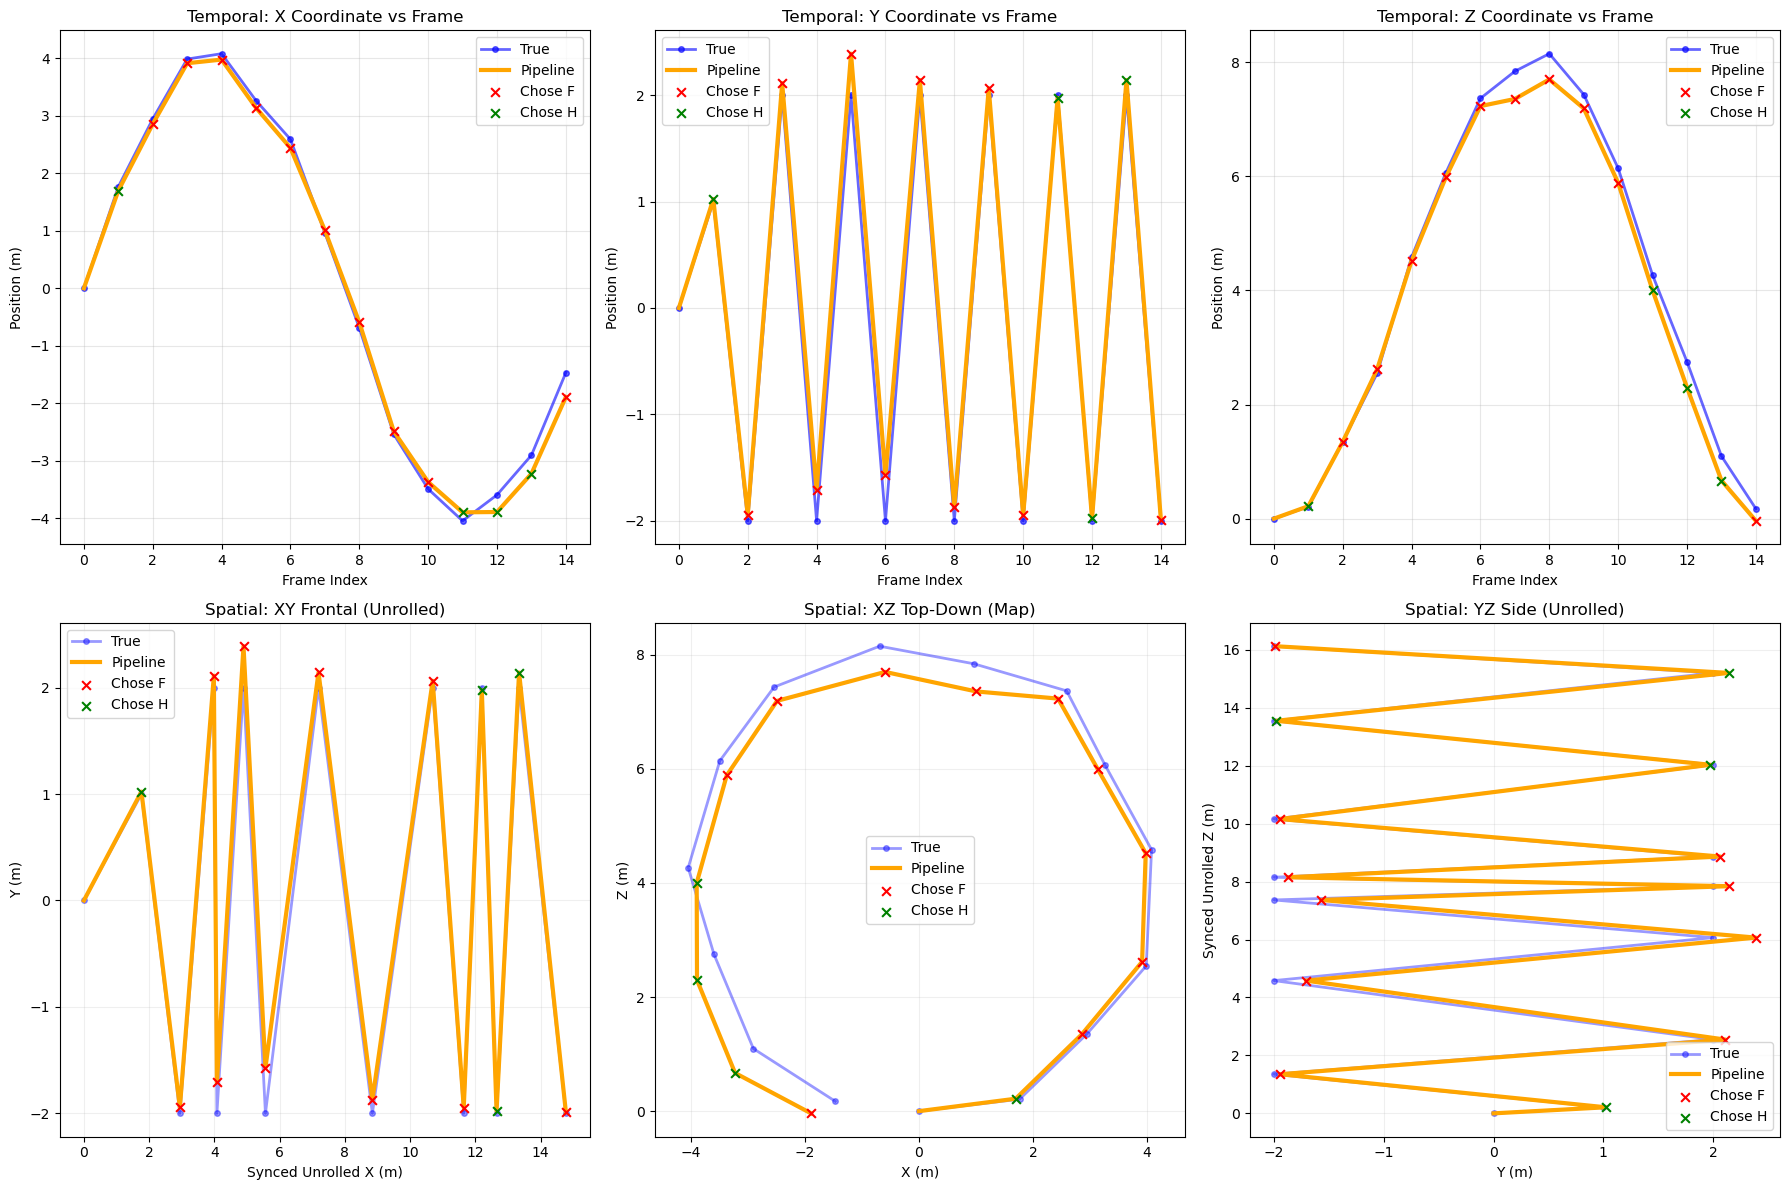

<Figure size 640x480 with 0 Axes>

Average Relative Translation Error: nan%


ValueError: operands could not be broadcast together with shapes (14,3) (15,3) 

In [210]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP & TRAJECTORY RECONSTRUCTION
# ==========================================
threshold = 0.59
nb_pose = len(true_t) + 1
nb_steps = nb_pose - 1

# Apply decision logic
est_t_score = np.array([est_t_H[i] if score_ratio[i] > threshold else est_t_F[i] for i in range(nb_steps)])

# Integrate positions
true_pos = np.zeros((nb_pose, 3))
est_pos_score = np.zeros((nb_pose, 3))
for i in range(nb_steps):
    true_pos[i+1, :] = true_pos[i, :] + true_t[i, :]
    est_pos_score[i+1, :] = est_pos_score[i, :] + est_t_score[i, :]

# ==========================================
# 2. COORDINATE UNROLLING (FOR SPATIAL)
# ==========================================
def unroll_axis(arr):
    diffs = np.abs(np.diff(arr))
    unrolled = np.zeros_like(arr)
    unrolled[1:] = np.cumsum(diffs)
    return unrolled

un_x_sync = unroll_axis(true_pos[:, 0])
un_z_sync = unroll_axis(true_pos[:, 2])
frames = np.arange(nb_pose)
used_F = score_ratio[:nb_steps] < threshold

# ==========================================
# 3. COMBINED MASTER FIGURE (2 Rows x 3 Columns)
# ==========================================
fig, axs = plt.subplots(2, 3, figsize=(18, 12))
dims = ['X Coordinate', 'Y Coordinate', 'Z Coordinate']

# --- ROW 1: TEMPORAL ANALYSIS (Dimensions vs Frame) ---
for i in range(3):
    ax = axs[0, i]
    ax.plot(frames, true_pos[:, i], label='True', color='blue', marker='o', markersize=4, lw=2, alpha=0.6)
    ax.plot(frames, est_pos_score[:, i], label='Pipeline', color='orange', linewidth=3)
    
    # Decision Markers
    ax.scatter(frames[1:][used_F], est_pos_score[1:][used_F, i], color='red', s=40, zorder=5, label='Chose F', marker='x')
    ax.scatter(frames[1:][~used_F], est_pos_score[1:][~used_F, i], color='green', s=40, zorder=5, label='Chose H', marker='x')
    
    ax.set_title(f"Temporal: {dims[i]} vs Frame")
    ax.set_xlabel("Frame Index")
    ax.set_ylabel("Position (m)")
    ax.grid(True, alpha=0.3)
    ax.legend()

# --- ROW 2: SPATIAL ANALYSIS (Planes) ---
for col in range(3):
    ax = axs[1, col]
    
    if col == 0: # XY Frontal (Unrolled X)
        h_t, h_p = un_x_sync, un_x_sync
        v_t, v_p = true_pos[:, 1], est_pos_score[:, 1]
        ax.set_xlabel("Synced Unrolled X (m)"); ax.set_ylabel("Y (m)")
        title = "Spatial: XY Frontal (Unrolled)"
        
    elif col == 1: # XZ Top-Down (Standard)
        h_t, h_p = true_pos[:, 0], est_pos_score[:, 0]
        v_t, v_p = true_pos[:, 2], est_pos_score[:, 2]
        ax.set_xlabel("X (m)"); ax.set_ylabel("Z (m)")
        title = "Spatial: XZ Top-Down (Map)"
        ax.axis('equal')
        
    else: # YZ Side (Unrolled Z)
        h_t, h_p = true_pos[:, 1], est_pos_score[:, 1]
        v_t, v_p = un_z_sync, un_z_sync
        ax.set_xlabel("Y (m)"); ax.set_ylabel("Synced Unrolled Z (m)")
        title = "Spatial: YZ Side (Unrolled)"

    # Plot spatial data
    ax.plot(h_t, v_t, 'b-', marker='o', markersize=4, lw=2, alpha=0.4, label='True')
    ax.plot(h_p, v_p, color='orange', lw=3, label='Pipeline')
    
    # Decision Markers
    ax.scatter(h_p[1:][used_F], v_p[1:][used_F], color='red', marker='x', s=40, zorder=5, label='Chose F')
    ax.scatter(h_p[1:][~used_F], v_p[1:][~used_F], color='green', marker='x', s=40, zorder=5, label='Chose H')
    
    ax.set_title(title)
    ax.grid(True, alpha=0.2)
    ax.legend()

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()
true_deltas = np.diff(true_pos, axis=0)
est_deltas  = np.diff(est_pos_score, axis=0)

# 2. Calculate the magnitude of the error vector for each step
error_vectors = est_deltas - true_deltas
rte_raw = np.linalg.norm(error_vectors, axis=1) # Error in units (e.g. meters)

# 3. Calculate normalized RTE (Error as a percentage of step length)
step_lengths = np.linalg.norm(true_deltas, axis=1)
rte_percent = (rte_raw / step_lengths) * 100

# 4. Final Metric: Mean RTE
mean_rte = np.mean(rte_percent)
print(f"Average Relative Translation Error: {mean_rte:.2f}%")

# F matrix
true_deltas = np.diff(true_pos, axis=0)
est_deltas  = np.diff(est_pos_F, axis=0)

# 2. Calculate the magnitude of the error vector for each step
error_vectors = est_deltas - true_deltas
rte_raw = np.linalg.norm(error_vectors, axis=1) # Error in units (e.g. meters)

# 3. Calculate normalized RTE (Error as a percentage of step length)
step_lengths = np.linalg.norm(true_deltas, axis=1)
rte_percent_F = (rte_raw / step_lengths) * 100

# 4. Final Metric: Mean RTE
mean_rte = np.mean(rte_percent_F)
print(f"Average Relative Translation Error: {mean_rte:.2f}%")

# H matrix
true_deltas = np.diff(true_pos, axis=0)
est_deltas  = np.diff(est_pos_H, axis=0)

# 2. Calculate the magnitude of the error vector for each step
error_vectors = est_deltas - true_deltas
rte_raw = np.linalg.norm(error_vectors, axis=1) # Error in units (e.g. meters)

# 3. Calculate normalized RTE (Error as a percentage of step length)
step_lengths = np.linalg.norm(true_deltas, axis=1)
rte_percent_H = (rte_raw / step_lengths) * 100

# 4. Final Metric: Mean RTE
mean_rte = np.mean(rte_percent_H)
print(f"Average Relative Translation Error: {mean_rte:.2f}%")

plt.figure(figsize=(12, 6))

# Plot the Raw F and H Errors (Faded into the background)
plt.plot(rte_percent_F, label='RTE (F Matrix)', 
         color='red', marker='x', linestyle='--', alpha=0.5)

plt.plot(rte_percent_H, label='RTE (H Matrix)', 
         color='green', marker='x', linestyle='--', alpha=0.5)

# Plot your Pipeline Error (Bold and brought to the front)
plt.plot(rte_percent, label='RTE (Pipeline)', 
         color='orange', linewidth=3, marker='o', zorder=5)

# Formatting the plot
plt.title('Relative Translation Error (RTE) per Step')
plt.xlabel('Step / Frame Index')
plt.ylabel('Relative Translation Error (%)')

# Set the bottom of the y-axis to 0% for proper perspective
plt.ylim(bottom=0) 

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

import numpy as np
from scipy.spatial.transform import Rotation as R

def calculate_step_rre(true_angles, est_angles):
    """
    Calculates the Relative Rotation Error (RRE) in degrees.
    true_angles, est_angles: [rx, ry, rz] in degrees
    """
    # 1. Convert Euler angles to Rotation Matrices
    # Using 'xyz' or 'zyx' depending on your simulator's convention
    r_true = R.from_euler('xyz', true_angles, degrees=True).as_matrix()
    r_est = R.from_euler('xyz', est_angles, degrees=True).as_matrix()
    
    # 2. Compute the relative rotation matrix
    # This represents the "rotation difference"
    r_diff = np.dot(r_true.T, r_est)
    
    # 3. Calculate the angle of this rotation (the Geodesic distance)
    # Formula: acos((trace(R_diff) - 1) / 2)
    cos_theta = (np.trace(r_diff) - 1.0) / 2.0
    
    # Clip to avoid floating point errors outside [-1, 1]
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    
    return np.degrees(np.arccos(cos_theta))

# --- Application ---
# Assuming est_r_score and true_r are arrays of shape (nb_pose, 3)
rre_per_step = []

for i in range(nb_pose - 1):
    # We compare the estimated rotation of the step to the true rotation
    error = calculate_step_rre(true_r[i], est_r_score[i])
    rre_per_step.append(error)

mean_rre = np.mean(rre_per_step)
print(f"Mean Relative Rotation Error: {mean_rre:.4f} degrees per step")

rre_per_step_F = []
# F
for i in range(nb_pose - 1):
    # We compare the estimated rotation of the step to the true rotation
    error = calculate_step_rre(true_r[i], est_r_F[i])
    rre_per_step_F.append(error)

mean_rre_F = np.mean(rre_per_step_F)
print(f"Mean Relative Rotation Error: {mean_rre_F:.4f} degrees per step")
rre_per_step_H = []
# H
for i in range(nb_pose - 1):
    # We compare the estimated rotation of the step to the true rotation
    error = calculate_step_rre(true_r[i], est_r_H[i])
    rre_per_step_H.append(error)

mean_rre_H = np.mean(rre_per_step_H)
print(f"Mean Relative Rotation Error: {mean_rre_H:.4f} degrees per step")

plt.figure(figsize=(12, 6))

# Plot the Raw F and H Rotation Errors (Faded into the background)
plt.plot(rre_per_step_F, label='RRE (F Matrix)', 
         color='red', marker='x', linestyle='--', alpha=0.5)

plt.plot(rre_per_step_H, label='RRE (H Matrix)', 
         color='green', marker='x', linestyle='--', alpha=0.5)

# Plot your Pipeline's Rotation Error (Bold and brought to the front)
plt.plot(rre_per_step, label='RRE (Pipeline)', 
         color='orange', linewidth=3, marker='o', zorder=5)

# Formatting the plot
plt.title('Relative Rotation Error (RRE) per Step')
plt.xlabel('Step / Frame Index')
plt.ylabel('Relative Rotation Error (Degrees)')

# Set the bottom of the y-axis to 0 degrees for proper perspective
plt.ylim(bottom=0) 

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [209]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
threshold = 0.45

for i in range (nb_pose-1):
    est_t_score[i, :] = est_t_H[i,:] if score_ratio[i] > threshold else est_t_F[i,:] 
    est_r_score[i, :] = est_r_H[i,:] if score_ratio[i] > threshold else est_r_F[i,:] 
true_pos = np.zeros((nb_pose, 3))
est_pos_F = np.zeros((nb_pose, 3))
est_pos_H = np.zeros((nb_pose, 3))
est_pos_score = np.zeros((nb_pose, 3))

for i in range(nb_pose-1):
    true_pos[i+1, :] = translate_point(true_pos[i, :], true_t[i, :])
    est_pos_F[i+1, :] = translate_point(est_pos_F[i, :], est_t_F[i, :])
    est_pos_H[i+1, :] = translate_point(est_pos_H[i, :], est_t_H[i, :])
    est_pos_score[i+1, :] = translate_point(est_pos_score[i, :], est_t_score[i, :])
# ==========================================
# 0. DATA PREPARATION (Plug your arrays in here)
# ==========================================
nb_pose = len(true_pos)
nb_steps = nb_pose - 1

# ==========================================
# 1. TRANSLATION ERROR (RTE)
# ==========================================
def calc_rte(true_p, est_p):
    true_deltas = np.diff(true_p, axis=0)
    est_deltas  = np.diff(est_p, axis=0)
    error_vectors = est_deltas - true_deltas
    rte_raw = np.linalg.norm(error_vectors, axis=1)
    step_lengths = np.linalg.norm(true_deltas, axis=1)
    step_lengths = np.where(step_lengths == 0, 1e-6, step_lengths) 
    return (rte_raw / step_lengths) * 100

rte_percent_pipeline = calc_rte(true_pos, est_pos_score)
rte_percent_F        = calc_rte(true_pos, est_pos_F)
rte_percent_H        = calc_rte(true_pos, est_pos_H)

mean_rte_pipeline = np.mean(rte_percent_pipeline)
mean_rte_F        = np.mean(rte_percent_F)
mean_rte_H        = np.mean(rte_percent_H)

# ==========================================
# 2. ROTATION ERROR (RRE)
# ==========================================
def calculate_step_rre(true_angles, est_angles):
    r_true = R.from_euler('xyz', true_angles, degrees=True).as_matrix()
    r_est = R.from_euler('xyz', est_angles, degrees=True).as_matrix()
    r_diff = np.dot(r_true.T, r_est)
    cos_theta = (np.trace(r_diff) - 1.0) / 2.0
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    return np.degrees(np.arccos(cos_theta))

rre_per_step, rre_per_step_F, rre_per_step_H = [], [], []

for i in range(nb_steps):
    rre_per_step.append(calculate_step_rre(true_r[i], est_r_score[i]))
    rre_per_step_F.append(calculate_step_rre(true_r[i], est_r_F[i]))
    rre_per_step_H.append(calculate_step_rre(true_r[i], est_r_H[i]))

mean_rre = np.mean(rre_per_step)
mean_rre_F = np.mean(rre_per_step_F)
mean_rre_H = np.mean(rre_per_step_H)

# ==========================================
# 3. ABSOLUTE TRAJECTORY ERROR (ATE) - NEW!
# ==========================================
def calc_ate_per_frame(true_p, est_p):
    return np.linalg.norm(est_p - true_p, axis=1)

ate_per_frame_pipeline = calc_ate_per_frame(true_pos, est_pos_score)
ate_per_frame_F        = calc_ate_per_frame(true_pos, est_pos_F)
ate_per_frame_H        = calc_ate_per_frame(true_pos, est_pos_H)

ate_rmse_pipeline = np.sqrt(np.mean(ate_per_frame_pipeline**2))
ate_rmse_F        = np.sqrt(np.mean(ate_per_frame_F**2))
ate_rmse_H        = np.sqrt(np.mean(ate_per_frame_H**2))

# ==========================================
# 4. FINAL DRIFT & DRIFT PER STEP
# ==========================================
final_drift_pipeline = np.linalg.norm(true_pos[-1] - est_pos_score[-1])
final_drift_F = np.linalg.norm(true_pos[-1] - est_pos_F[-1])
final_drift_H = np.linalg.norm(true_pos[-1] - est_pos_H[-1])

drift_per_step_pipeline = final_drift_pipeline / nb_steps
drift_per_step_F = final_drift_F / nb_steps
drift_per_step_H = final_drift_H / nb_steps

# ==========================================
# 5. MASTER SUMMARY REPORT
# ==========================================
print("==================================================")
print("           PIPELINE EVALUATION METRICS            ")
print("==================================================")
print("\n=== 1. MEAN RELATIVE TRANSLATION ERROR (RTE) ===")
print(f"  Pipeline : {mean_rte_pipeline:.2f}%")
print(f"  F Matrix : {mean_rte_F:.2f}%")
print(f"  H Matrix : {mean_rte_H:.2f}%")

print("\n=== 2. MEAN RELATIVE ROTATION ERROR (RRE) ===")
print(f"  Pipeline : {mean_rre:.4f} degrees/step")
print(f"  F Matrix : {mean_rre_F:.4f} degrees/step")
print(f"  H Matrix : {mean_rre_H:.4f} degrees/step")

print("\n=== 3. ABSOLUTE TRAJECTORY ERROR (ATE RMSE) ===")
print(f"  Pipeline : {ate_rmse_pipeline:.4f} m")
print(f"  F Matrix : {ate_rmse_F:.4f} m")
print(f"  H Matrix : {ate_rmse_H:.4f} m")

print("\n=== 4. FINAL DRIFT ===")
print(f"  Pipeline : {final_drift_pipeline:.4f} m")
print(f"  F Matrix : {final_drift_F:.4f} m")
print(f"  H Matrix : {final_drift_H:.4f} m")

print("\n=== 5. DRIFT PER STEP ===")
print(f"  Pipeline : {drift_per_step_pipeline:.4f} m/step")
print(f"  F Matrix : {drift_per_step_F:.4f} m/step")
print(f"  H Matrix : {drift_per_step_H:.4f} m/step")
print("==================================================")



def calc_plane_metrics(true_p, est_p, axis_indices, nb_steps):
    """
    Calculates RTE, ATE RMSE, Final Drift, and Drift per Step for specific planes.
    """
    t_plane = true_p[:, axis_indices]
    e_plane = est_p[:, axis_indices]
    
    # --- 1. RTE (Relative Translation Error) ---
    t_deltas = np.diff(t_plane, axis=0)
    e_deltas = np.diff(e_plane, axis=0)
    rte_raw = np.linalg.norm(e_deltas - t_deltas, axis=1)
    step_lens = np.linalg.norm(t_deltas, axis=1)
    step_lens = np.where(step_lens == 0, 1e-6, step_lens)
    mean_rte = np.mean((rte_raw / step_lens) * 100)
    
    # --- 2. ATE RMSE (Absolute Trajectory Error) ---
    ate_per_frame = np.linalg.norm(e_plane - t_plane, axis=1)
    rmse_ate = np.sqrt(np.mean(ate_per_frame**2))
    
    # --- 3. FINAL DRIFT ---
    final_drift = np.linalg.norm(e_plane[-1] - t_plane[-1])
    
    # --- 4. DRIFT PER STEP ---
    drift_per_step = final_drift / nb_steps
    
    return mean_rte, rmse_ate, final_drift, drift_per_step

# ==========================================
# 2. CALCULATION FOR ALL PLANES
# ==========================================

planes = {
    "XY (Frontal)": [0, 1],
    "XZ (Top-Down)": [0, 2],
    "YZ (Side)":     [1, 2]
}

results = {}

for name, idx in planes.items():
    res_pipe = calc_plane_metrics(true_pos, est_pos_score, idx, nb_steps)
    res_F    = calc_plane_metrics(true_pos, est_pos_F, idx, nb_steps)
    res_H    = calc_plane_metrics(true_pos, est_pos_H, idx, nb_steps)
    results[name] = {"Pipeline": res_pipe, "F": res_F, "H": res_H}

# ==========================================
# 3. COMPREHENSIVE MASTER REPORT
# ==========================================
print("="*60)
print(f"      3-PLANE PERFORMANCE ANALYSIS (T={threshold})")
print("="*60)

for name in planes.keys():
    p = results[name]["Pipeline"]
    f = results[name]["F"]
    h = results[name]["H"]
    
    print(f"\n[{name} Plane]")
    print(f"  Metric              | Pipeline   | F-Matrix   | H-Matrix")
    print(f"  --------------------|------------|------------|------------")
    print(f"  Mean RTE (%)        | {p[0]:10.2f} | {f[0]:10.2f} | {h[0]:10.2f}")
    print(f"  ATE RMSE (m)        | {p[1]:10.4f} | {f[1]:10.4f} | {h[1]:10.4f}")
    print(f"  Final Drift (m)     | {p[2]:10.4f} | {f[2]:10.4f} | {h[2]:10.4f}")
    print(f"  Drift/Step (m)      | {p[3]:10.4f} | {f[3]:10.4f} | {h[3]:10.4f}")

print("\n" + "="*60)
print(f"  GLOBAL ROTATION ERROR: {np.mean(rre_per_step):.4f} deg/step")
print("="*60)

           PIPELINE EVALUATION METRICS            

=== 1. MEAN RELATIVE TRANSLATION ERROR (RTE) ===
  Pipeline : 8.75%
  F Matrix : 20.37%
  H Matrix : 11.60%

=== 2. MEAN RELATIVE ROTATION ERROR (RRE) ===
  Pipeline : 1.4316 degrees/step
  F Matrix : 2.6092 degrees/step
  H Matrix : 2.1480 degrees/step

=== 3. ABSOLUTE TRAJECTORY ERROR (ATE RMSE) ===
  Pipeline : 1.3400 m
  F Matrix : 1.9694 m
  H Matrix : 1.4761 m

=== 4. FINAL DRIFT ===
  Pipeline : 1.2315 m
  F Matrix : 2.3403 m
  H Matrix : 1.3235 m

=== 5. DRIFT PER STEP ===
  Pipeline : 0.0880 m/step
  F Matrix : 0.1672 m/step
  H Matrix : 0.0945 m/step
      3-PLANE PERFORMANCE ANALYSIS (T=0.45)

[XY (Frontal) Plane]
  Metric              | Pipeline   | F-Matrix   | H-Matrix
  --------------------|------------|------------|------------
  Mean RTE (%)        |       8.73 |      19.46 |      11.77
  ATE RMSE (m)        |     1.1102 |     1.9222 |     1.2558
  Final Drift (m)     |     0.4253 |     2.1685 |     0.5515
  Drift/Ste

In [204]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
threshold = 0.59

for i in range (nb_pose-1):
    est_t_score[i, :] = est_t_H[i,:] if score_ratio[i] > threshold else est_t_F[i,:] 
    est_r_score[i, :] = est_r_H[i,:] if score_ratio[i] > threshold else est_r_F[i,:] 
true_pos = np.zeros((nb_pose, 3))
est_pos_F = np.zeros((nb_pose, 3))
est_pos_H = np.zeros((nb_pose, 3))
est_pos_score = np.zeros((nb_pose, 3))

for i in range(nb_pose-1):
    true_pos[i+1, :] = translate_point(true_pos[i, :], true_t[i, :])
    est_pos_F[i+1, :] = translate_point(est_pos_F[i, :], est_t_F[i, :])
    est_pos_H[i+1, :] = translate_point(est_pos_H[i, :], est_t_H[i, :])
    est_pos_score[i+1, :] = translate_point(est_pos_score[i, :], est_t_score[i, :])
# ==========================================
# 0. DATA PREPARATION (Plug your arrays in here)
# ==========================================
nb_pose = len(true_pos)
nb_steps = nb_pose - 1

# ==========================================
# 1. TRANSLATION ERROR (RTE)
# ==========================================
def calc_rte(true_p, est_p):
    true_deltas = np.diff(true_p, axis=0)
    est_deltas  = np.diff(est_p, axis=0)
    error_vectors = est_deltas - true_deltas
    rte_raw = np.linalg.norm(error_vectors, axis=1)
    step_lengths = np.linalg.norm(true_deltas, axis=1)
    step_lengths = np.where(step_lengths == 0, 1e-6, step_lengths) 
    return (rte_raw / step_lengths) * 100

rte_percent_pipeline = calc_rte(true_pos, est_pos_score)
rte_percent_F        = calc_rte(true_pos, est_pos_F)
rte_percent_H        = calc_rte(true_pos, est_pos_H)

mean_rte_pipeline = np.mean(rte_percent_pipeline)
mean_rte_F        = np.mean(rte_percent_F)
mean_rte_H        = np.mean(rte_percent_H)

# ==========================================
# 2. ROTATION ERROR (RRE)
# ==========================================
def calculate_step_rre(true_angles, est_angles):
    r_true = R.from_euler('xyz', true_angles, degrees=True).as_matrix()
    r_est = R.from_euler('xyz', est_angles, degrees=True).as_matrix()
    r_diff = np.dot(r_true.T, r_est)
    cos_theta = (np.trace(r_diff) - 1.0) / 2.0
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    return np.degrees(np.arccos(cos_theta))

rre_per_step, rre_per_step_F, rre_per_step_H = [], [], []

for i in range(nb_steps):
    rre_per_step.append(calculate_step_rre(true_r[i], est_r_score[i]))
    rre_per_step_F.append(calculate_step_rre(true_r[i], est_r_F[i]))
    rre_per_step_H.append(calculate_step_rre(true_r[i], est_r_H[i]))

mean_rre = np.mean(rre_per_step)
mean_rre_F = np.mean(rre_per_step_F)
mean_rre_H = np.mean(rre_per_step_H)

# ==========================================
# 3. ABSOLUTE TRAJECTORY ERROR (ATE) - NEW!
# ==========================================
def calc_ate_per_frame(true_p, est_p):
    return np.linalg.norm(est_p - true_p, axis=1)

ate_per_frame_pipeline = calc_ate_per_frame(true_pos, est_pos_score)
ate_per_frame_F        = calc_ate_per_frame(true_pos, est_pos_F)
ate_per_frame_H        = calc_ate_per_frame(true_pos, est_pos_H)

ate_rmse_pipeline = np.sqrt(np.mean(ate_per_frame_pipeline**2))
ate_rmse_F        = np.sqrt(np.mean(ate_per_frame_F**2))
ate_rmse_H        = np.sqrt(np.mean(ate_per_frame_H**2))

# ==========================================
# 4. FINAL DRIFT & DRIFT PER STEP
# ==========================================
final_drift_pipeline = np.linalg.norm(true_pos[-1] - est_pos_score[-1])
final_drift_F = np.linalg.norm(true_pos[-1] - est_pos_F[-1])
final_drift_H = np.linalg.norm(true_pos[-1] - est_pos_H[-1])

drift_per_step_pipeline = final_drift_pipeline / nb_steps
drift_per_step_F = final_drift_F / nb_steps
drift_per_step_H = final_drift_H / nb_steps

# ==========================================
# 5. MASTER SUMMARY REPORT
# ==========================================
print("==================================================")
print("           PIPELINE EVALUATION METRICS  059       ")
print("==================================================")
print("\n=== 1. MEAN RELATIVE TRANSLATION ERROR (RTE) ===")
print(f"  Pipeline : {mean_rte_pipeline:.2f}%")
print(f"  F Matrix : {mean_rte_F:.2f}%")
print(f"  H Matrix : {mean_rte_H:.2f}%")

print("\n=== 2. MEAN RELATIVE ROTATION ERROR (RRE) ===")
print(f"  Pipeline : {mean_rre:.4f} degrees/step")
print(f"  F Matrix : {mean_rre_F:.4f} degrees/step")
print(f"  H Matrix : {mean_rre_H:.4f} degrees/step")

print("\n=== 3. ABSOLUTE TRAJECTORY ERROR (ATE RMSE) ===")
print(f"  Pipeline : {ate_rmse_pipeline:.4f} m")
print(f"  F Matrix : {ate_rmse_F:.4f} m")
print(f"  H Matrix : {ate_rmse_H:.4f} m")

print("\n=== 4. FINAL DRIFT ===")
print(f"  Pipeline : {final_drift_pipeline:.4f} m")
print(f"  F Matrix : {final_drift_F:.4f} m")
print(f"  H Matrix : {final_drift_H:.4f} m")

print("\n=== 5. DRIFT PER STEP ===")
print(f"  Pipeline : {drift_per_step_pipeline:.4f} m/step")
print(f"  F Matrix : {drift_per_step_F:.4f} m/step")
print(f"  H Matrix : {drift_per_step_H:.4f} m/step")
print("==================================================")

import numpy as np

# ==========================================
# 1. UPDATED EVALUATION FUNCTION
# ==========================================

def calc_plane_metrics(true_p, est_p, axis_indices, nb_steps):
    """
    Calculates RTE, ATE RMSE, Final Drift, and Drift per Step for specific planes.
    """
    t_plane = true_p[:, axis_indices]
    e_plane = est_p[:, axis_indices]
    
    # --- 1. RTE (Relative Translation Error) ---
    t_deltas = np.diff(t_plane, axis=0)
    e_deltas = np.diff(e_plane, axis=0)
    rte_raw = np.linalg.norm(e_deltas - t_deltas, axis=1)
    step_lens = np.linalg.norm(t_deltas, axis=1)
    step_lens = np.where(step_lens == 0, 1e-6, step_lens)
    mean_rte = np.mean((rte_raw / step_lens) * 100)
    
    # --- 2. ATE RMSE (Absolute Trajectory Error) ---
    ate_per_frame = np.linalg.norm(e_plane - t_plane, axis=1)
    rmse_ate = np.sqrt(np.mean(ate_per_frame**2))
    
    # --- 3. FINAL DRIFT ---
    final_drift = np.linalg.norm(e_plane[-1] - t_plane[-1])
    
    # --- 4. DRIFT PER STEP ---
    drift_per_step = final_drift / nb_steps
    
    return mean_rte, rmse_ate, final_drift, drift_per_step

# ==========================================
# 2. CALCULATION FOR ALL PLANES
# ==========================================

planes = {
    "XY (Frontal)": [0, 1],
    "XZ (Top-Down)": [0, 2],
    "YZ (Side)":     [1, 2]
}

results = {}

for name, idx in planes.items():
    res_pipe = calc_plane_metrics(true_pos, est_pos_score, idx, nb_steps)
    res_F    = calc_plane_metrics(true_pos, est_pos_F, idx, nb_steps)
    res_H    = calc_plane_metrics(true_pos, est_pos_H, idx, nb_steps)
    results[name] = {"Pipeline": res_pipe, "F": res_F, "H": res_H}

# ==========================================
# 3. COMPREHENSIVE MASTER REPORT
# ==========================================
print("="*60)
print(f"      3-PLANE PERFORMANCE ANALYSIS (T={threshold})")
print("="*60)

for name in planes.keys():
    p = results[name]["Pipeline"]
    f = results[name]["F"]
    h = results[name]["H"]
    
    print(f"\n[{name} Plane]")
    print(f"  Metric              | Pipeline   | F-Matrix   | H-Matrix")
    print(f"  --------------------|------------|------------|------------")
    print(f"  Mean RTE (%)        | {p[0]:10.2f} | {f[0]:10.2f} | {h[0]:10.2f}")
    print(f"  ATE RMSE (m)        | {p[1]:10.4f} | {f[1]:10.4f} | {h[1]:10.4f}")
    print(f"  Final Drift (m)     | {p[2]:10.4f} | {f[2]:10.4f} | {h[2]:10.4f}")
    print(f"  Drift/Step (m)      | {p[3]:10.4f} | {f[3]:10.4f} | {h[3]:10.4f}")

print("\n" + "="*60)
print(f"  GLOBAL ROTATION ERROR: {np.mean(rre_per_step):.4f} deg/step")
print("="*60)

           PIPELINE EVALUATION METRICS  059       

=== 1. MEAN RELATIVE TRANSLATION ERROR (RTE) ===
  Pipeline : 4.13%
  F Matrix : 20.37%
  H Matrix : 11.60%

=== 2. MEAN RELATIVE ROTATION ERROR (RRE) ===
  Pipeline : 0.4783 degrees/step
  F Matrix : 2.6092 degrees/step
  H Matrix : 2.1480 degrees/step

=== 3. ABSOLUTE TRAJECTORY ERROR (ATE RMSE) ===
  Pipeline : 0.3729 m
  F Matrix : 1.9694 m
  H Matrix : 1.4761 m

=== 4. FINAL DRIFT ===
  Pipeline : 0.4736 m
  F Matrix : 2.3403 m
  H Matrix : 1.3235 m

=== 5. DRIFT PER STEP ===
  Pipeline : 0.0338 m/step
  F Matrix : 0.1672 m/step
  H Matrix : 0.0945 m/step
      3-PLANE PERFORMANCE ANALYSIS (T=0.59)

[XY (Frontal) Plane]
  Metric              | Pipeline   | F-Matrix   | H-Matrix
  --------------------|------------|------------|------------
  Mean RTE (%)        |       3.37 |      19.46 |      11.77
  ATE RMSE (m)        |     0.2567 |     1.9222 |     1.2558
  Final Drift (m)     |     0.4237 |     2.1685 |     0.5515
  Drift/Ste

Optimal Threshold: 0.59
Minimum ATE RMSE: 0.3729 meters


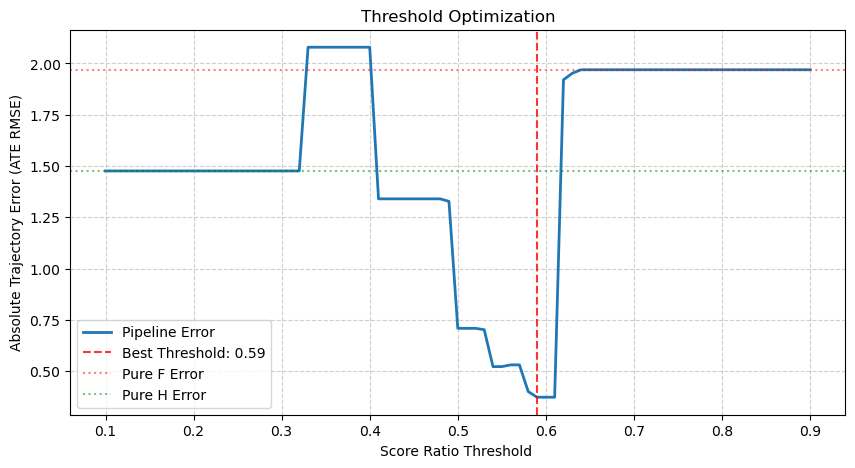

In [208]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup the search range
# We test 81 different values from 0.10 to 0.90
thresholds = np.linspace(0.1, 0.9, 81)
ate_results = []

# 2. Optimization Loop
for t_val in thresholds:
    # Initialize a fresh trajectory for each test
    temp_pos = np.zeros((nb_pose, 3))
    
    for i in range(nb_steps):
        # Decision logic: Choose H if score > threshold, else F
        # This is the 'switching' mechanism we are testing
        rel_t = est_t_H[i, :] if score_ratio[i] > t_val else est_t_F[i, :]
        
        # Integrate the relative translation into a global position
        temp_pos[i+1] = temp_pos[i] + rel_t
    
    # Calculate the Global Error (ATE RMSE) for this specific threshold
    err = np.linalg.norm(temp_pos - true_pos, axis=1)
    ate_rmse = np.sqrt(np.mean(err**2))
    ate_results.append(ate_rmse)

# 3. Identify the Best Threshold
best_idx = np.argmin(ate_results)
best_t = thresholds[best_idx]
min_error = ate_results[best_idx]

print(f"Optimal Threshold: {best_t:.2f}")
print(f"Minimum ATE RMSE: {min_error:.4f} meters")

# 4. Plot the results
plt.figure(figsize=(10, 5))
plt.plot(thresholds, ate_results, color='#1f77b4', linewidth=2, label='Pipeline Error')

# Mark the best threshold with a red dashed line
plt.axvline(best_t, color='red', linestyle='--', alpha=0.8, 
            label=f'Best Threshold: {best_t:.2f}')

# Reference lines (Assuming these were calculated earlier)
plt.axhline(ate_rmse_F, color='red', linestyle=':', alpha=0.5, label='Pure F Error')
plt.axhline(ate_rmse_H, color='green', linestyle=':', alpha=0.5, label='Pure H Error')

plt.title('Threshold Optimization')
plt.xlabel('Score Ratio Threshold ')
plt.ylabel('Absolute Trajectory Error (ATE RMSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()